# SPF Performance Analysis & Visualization

Notebook ini berfungsi sebagai pipeline analisis untuk mengolah data performa algoritma SPF (A*, Bellman-Ford, dan Widest Path) yang dieksekusi menggunakan Mininet dan OSKen. Data dibaca dari berkas CSV hasil konversi scenario-mode.

## Topologi yang Dianalisis
- **Jellyfish** — topologi acak dengan 10 switch, 10 host (seed 42)
- **Ring-5** — topologi ring dengan 5 switch, 10 host (2 host per switch)

## Algoritma yang Dibandingkan
- **A*** — heuristik shortest path
- **Bellman-Ford** — dynamic programming shortest path
- **Widest Path** — maximum bottleneck bandwidth path

## Tahapan Analisis
1. Setup & Konfigurasi
2. Deteksi File Input (Discovery)
3. Pemuatan & Validasi Data (Load & Validate)
4. Normalisasi & Pengayaan Data (Normalize & Enrich)
5. Perhitungan Statistik Ringkasan (Summary Statistics)
   - 5A. Analisis Failure Recovery
   - 5B. Analisis Error & Anomali
   - 5C. Ranking & Rekomendasi Algoritma
6. Pembuatan Tabel Perbandingan (Pivot Tables)
7. Pembuatan Plot Visualisasi (7A–7H)
8. Ekspor Hasil Analisis

---
### Cell 1: Setup & Config
Menyiapkan pustaka, gaya visual, color palette konsisten, dan path folder.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from pathlib import Path
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=FutureWarning)

# ── Style ──────────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18,
    'figure.dpi': 150,
    'savefig.bbox': 'tight',
})

# ── Konsistensi Warna per Algoritma ─────────────────────
ALGO_COLORS = {
    'astar':        '#2196F3',  # biru
    'bellman_ford':  '#FF9800',  # oranye
    'widest_path':  '#4CAF50',  # hijau
}
ALGO_LABELS = {
    'astar':        'A*',
    'bellman_ford':  'Bellman-Ford',
    'widest_path':  'Widest Path',
}
TOPO_MARKERS = {'jellyfish': 'o', 'ring5': 's'}

# ── Path Folder ────────────────────────────────────────
BASE_DIR = Path("/content")

# CSV dirs per topologi
CSV_DIRS = {
    'jellyfish': BASE_DIR / "jellyfish" / "csv" / "jellyfish-csv",
    'ring5':     BASE_DIR / "ring5"     / "csv" / "ring5-csv",
}

# PCAP CSV dirs per topologi
PCAP_DIRS = {
    'jellyfish': BASE_DIR / "jellyfish" / "csv" / "pcap-csv",
    'ring5':     BASE_DIR / "ring5"     / "csv" / "pcap-csv",
}

IMG_DIR          = BASE_DIR / "img" / "analysis"
ANALYSIS_OUT_DIR = BASE_DIR / "analysis_output"

IMG_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_OUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_SVG = True

def save_figure(fig, name):
    """Simpan figure sebagai PNG dan opsional SVG."""
    fig.savefig(IMG_DIR / f'{name}.png', dpi=300)
    if SAVE_SVG:
        fig.savefig(IMG_DIR / f'{name}.svg', format='svg')
    print(f'  Saved: {name}.png' + (' + .svg' if SAVE_SVG else ''))

print(f"Direktori Utama   : {BASE_DIR.resolve()}")
for topo, d in CSV_DIRS.items():
    print(f"Direktori CSV [{topo:10s}]: {d.resolve()}")
for topo, d in PCAP_DIRS.items():
    print(f"Direktori PCAP [{topo:10s}]: {d.resolve()}")
print(f"Direktori Gambar  : {IMG_DIR.resolve()}")
print(f"Direktori CSV Out : {ANALYSIS_OUT_DIR.resolve()}")

Direktori Utama   : /content
Direktori CSV [jellyfish ]: /content/jellyfish/csv/jellyfish-csv
Direktori CSV [ring5     ]: /content/ring5/csv/ring5-csv
Direktori PCAP [jellyfish ]: /content/jellyfish/csv/pcap-csv
Direktori PCAP [ring5     ]: /content/ring5/csv/pcap-csv
Direktori Gambar  : /content/img/analysis
Direktori CSV Out : /content/analysis_output


---
### Cell 2: Discover Inputs
Mendeteksi semua berkas `*-scenarios.csv` dan menampilkan inventory table.

In [ ]:
# ── Scan Scenario CSVs ─────────────────────────────────
scenario_csvs = []
for topo, csv_dir in CSV_DIRS.items():
    if csv_dir.exists():
        found = sorted(csv_dir.glob("*.csv"))
        scenario_csvs.extend(found)
        print(f"\nMenemukan {len(found)} CSV di {topo}:")
        for p in found:
            print(f"  - {p.name}  ({p.stat().st_size / 1024:.1f} KB)")
    else:
        print(f"\n⚠️  WARNING: Direktori tidak ditemukan: {csv_dir}")

# ── Scan PCAP CSVs ─────────────────────────────────────
pcap_csvs = []
for topo, pcap_dir in PCAP_DIRS.items():
    if pcap_dir.exists():
        found = sorted(pcap_dir.glob("**/*.csv"))
        pcap_csvs.extend(found)
        print(f"\nMenemukan {len(found)} PCAP CSV di {topo}:")
        for p in found[:5]:
            print(f"  - {p.relative_to(BASE_DIR)}")
        if len(found) > 5:
            print(f"    ... dan {len(found)-5} lainnya")
    else:
        print(f"\n⚠️  WARNING: Direktori PCAP tidak ditemukan: {pcap_dir}")

print(f"\nTotal scenario CSV : {len(scenario_csvs)}")
print(f"Total PCAP CSV     : {len(pcap_csvs)}")

# ── Inventory Table ────────────────────────────────────
if scenario_csvs:
    inv_rows = []
    for p in scenario_csvs:
        tmp = pd.read_csv(p, usecols=['topology', 'algorithm', 'scenario_name'])
        inv_rows.append({
            'File':       p.name,
            'Rows':       len(tmp),
            'Topologies': ', '.join(sorted(tmp['topology'].unique())),
            'Algorithms': tmp['algorithm'].nunique(),
            'Scenarios':  tmp['scenario_name'].nunique(),
        })
    inv_df = pd.DataFrame(inv_rows)
    display(inv_df)

    all_topos = set()
    for row in inv_rows:
        all_topos.update(row['Topologies'].split(', '))
    if len(all_topos) < 2:
        print("\n⚠️  WARNING: Kurang dari 2 topologi terdeteksi. Panduan Proyek Akhir"
              " mensyaratkan minimal 2 topologi untuk Topik 1.")
else:
    print("\n❌ ERROR: Tidak ada scenario CSV ditemukan.")
    for topo, d in CSV_DIRS.items():
        print(f"  [{topo}] {d.resolve()}")


Menemukan 3 CSV di jellyfish:
  - topology-jellyfish_algorithm-astar.csv  (3063.4 KB)
  - topology-jellyfish_algorithm-bellman_ford.csv  (3268.8 KB)
  - topology-jellyfish_algorithm-widest_path.csv  (3244.7 KB)

Menemukan 3 CSV di ring5:
  - topology-ring5_algorithm-astar.csv  (2465.5 KB)
  - topology-ring5_algorithm-bellman_ford.csv  (2641.8 KB)
  - topology-ring5_algorithm-widest_path.csv  (2619.2 KB)

Menemukan 210 PCAP CSV di jellyfish:
  - jellyfish/csv/pcap-csv/jellyfish/astar/bandwidth_throttle/run_scenario_jellyfish_astar_bandwidth_throttle_20260603_195833/h0.csv
  - jellyfish/csv/pcap-csv/jellyfish/astar/bandwidth_throttle/run_scenario_jellyfish_astar_bandwidth_throttle_20260603_195833/h1.csv
  - jellyfish/csv/pcap-csv/jellyfish/astar/bandwidth_throttle/run_scenario_jellyfish_astar_bandwidth_throttle_20260603_195833/h2.csv
  - jellyfish/csv/pcap-csv/jellyfish/astar/bandwidth_throttle/run_scenario_jellyfish_astar_bandwidth_throttle_20260603_195833/h3.csv
  - jellyfish/csv/pcap

,File,Rows,Topologies,Algorithms,Scenarios
0,topology-jellyfish_algorithm-astar.csv,700,jellyfish,1,7
1,topology-jellyfish_algorithm-bellman_ford.csv,700,jellyfish,1,7
2,topology-jellyfish_algorithm-widest_path.csv,700,jellyfish,1,7
3,topology-ring5_algorithm-astar.csv,600,ring5,1,6
4,topology-ring5_algorithm-bellman_ford.csv,600,ring5,1,6
5,topology-ring5_algorithm-widest_path.csv,600,ring5,1,6


---
### Cell 3: Load & Validate
Membaca **semua** scenario CSV, menggabungkannya, dan memvalidasi kelengkapan kolom wajib.

In [ ]:
# ── Load & Concat ──────────────────────────────────────
frames = []
for p in scenario_csvs:
    tmp = pd.read_csv(p)
    print(f"  Loaded {p.name}: {len(tmp)} rows")
    frames.append(tmp)

if frames:
    df = pd.concat(frames, ignore_index=True)
else:
    df = pd.DataFrame()

print(f"\nTotal baris gabungan: {len(df)}")

# ── Validasi Kolom Wajib ────────────────────────────────
MANDATORY_COLS = [
    'topology', 'algorithm', 'scenario_name', 'scenario_phase',
    'throughput_mbps', 'runtime_ms', 'hop_count', 'pingall_loss_pct',
    'status', 'error',
]

missing_cols = [c for c in MANDATORY_COLS if c not in df.columns]
if missing_cols:
    print(f"\n⚠️  Kolom wajib hilang: {missing_cols}")
else:
    print("\n✅ Semua kolom wajib tersedia.")

# ── Ringkasan per Topologi ──────────────────────────────
if not df.empty:
    summary = df.groupby('topology').agg(
        total_rows=('status', 'count'),
        success=('status', lambda x: (x == 'success').sum()),
        errors=('status', lambda x: (x == 'error').sum()),
        algorithms=('algorithm', 'nunique'),
        scenarios=('scenario_name', 'nunique'),
    )
    summary['error_rate_%'] = (summary['errors'] / summary['total_rows'] * 100).round(1)
    display(summary)

    # Missing values per kolom
    mv = df[MANDATORY_COLS].isnull().sum()
    mv = mv[mv > 0]
    if len(mv) > 0:
        print("\n⚠️  Missing values:")
        for col, cnt in mv.items():
            print(f"    {col}: {cnt} ({cnt/len(df)*100:.1f}%)")
    else:
        print("\nTidak ada missing values pada kolom wajib.")

  Loaded topology-jellyfish_algorithm-astar.csv: 700 rows
  Loaded topology-jellyfish_algorithm-bellman_ford.csv: 700 rows
  Loaded topology-jellyfish_algorithm-widest_path.csv: 700 rows
  Loaded topology-ring5_algorithm-astar.csv: 600 rows
  Loaded topology-ring5_algorithm-bellman_ford.csv: 600 rows
  Loaded topology-ring5_algorithm-widest_path.csv: 600 rows

Total baris gabungan: 3900

✅ Semua kolom wajib tersedia.


,total_rows,success,errors,algorithms,scenarios,error_rate_%
topology,,,,,,
jellyfish,2100,1876,224,3,7,10.7
ring5,1800,1635,165,3,6,9.2



⚠️  Missing values:
    throughput_mbps: 389 (10.0%)
    error: 3511 (90.0%)


---
### Cell 4: Normalize & Enrich
Konversi tipe data, pembuatan kolom pelengkap, dan pemisahan data error.

In [ ]:
if not df.empty:
    # ── Konversi numerik ─────────────────────────────────
    for col in ['throughput_mbps', 'runtime_ms', 'hop_count',
                'path_cost', 'pingall_loss_pct', 'bottleneck_mbps']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['pingall_loss_pct'] = df['pingall_loss_pct'].fillna(0.0)

    # ── Pair ID ──────────────────────────────────────────
    if {'source_host', 'destination_host'}.issubset(df.columns):
        df['pair_id'] = df.apply(
            lambda r: f"{min(str(r['source_host']),str(r['destination_host']))}"
                      f"-{max(str(r['source_host']),str(r['destination_host']))}",
            axis=1
        )

    # ── Scenario label (untuk plot) ──────────────────────
    df['scenario_label'] = df['scenario_name'].str.replace('_', ' ').str.title()

    # ── Algorithm label ──────────────────────────────────
    df['algo_label'] = df['algorithm'].map(ALGO_LABELS).fillna(df['algorithm'])

    # ── Failure classification ───────────────────────────
    df['is_failure_scenario'] = ~df['scenario_name'].isin(['baseline_no_failure'])

    SCENARIO_CATEGORIES = {
        'baseline_no_failure':        'baseline',
        'link_down_before_traffic':   'link_failure',
        'link_down_during_traffic':   'link_failure',
        'link_flap':                  'link_failure',
        'switch_down':                'node_failure',
        'bandwidth_throttle':         'degradation',
        'random_link_down_jellyfish': 'link_failure',
    }
    df['scenario_category'] = df['scenario_name'].map(SCENARIO_CATEGORIES).fillna('other')

    # ── Retransmits from iperf_summary JSON ──────────────
    def _extract_retransmits(summary_str):
        try:
            d = json.loads(summary_str)
            return d.get('sum_sent', {}).get('retransmits', 0)
        except (json.JSONDecodeError, TypeError):
            return np.nan

    if 'iperf_summary' in df.columns:
        df['retransmits'] = df['iperf_summary'].apply(_extract_retransmits)
    else:
        df['retransmits'] = np.nan

    # ── Throughput ratio ─────────────────────────────────
    if 'bottleneck_mbps' in df.columns:
        df['throughput_ratio'] = (
            df['throughput_mbps'] / df['bottleneck_mbps'].replace(0, np.nan)
        )

    # ── Pisahkan error rows ──────────────────────────────
    df_errors = df[df['status'] == 'error'].copy()
    df_ok     = df[df['status'] == 'success'].copy()

    print(f"Data valid (success): {len(df_ok)} rows")
    print(f"Data error          : {len(df_errors)} rows")
    print(f"Kolom tambahan      : pair_id, scenario_label, algo_label,"
          f" is_failure_scenario, scenario_category, retransmits, throughput_ratio")

    df_ok.head(3)

Data valid (success): 3511 rows
Data error          : 389 rows
Kolom tambahan      : pair_id, scenario_label, algo_label, is_failure_scenario, scenario_category, retransmits, throughput_ratio


---
### Cell 5: Summary Statistics
Metrik agregat per kombinasi topologi × algoritma × skenario.

In [ ]:
if not df_ok.empty:
    summary_stats = df_ok.groupby(['topology', 'algorithm', 'scenario_label']).agg(
        avg_throughput   = ('throughput_mbps', 'mean'),
        median_throughput= ('throughput_mbps', 'median'),
        std_throughput   = ('throughput_mbps', 'std'),
        min_throughput   = ('throughput_mbps', 'min'),
        max_throughput   = ('throughput_mbps', 'max'),
        avg_runtime_ms   = ('runtime_ms', 'mean'),
        std_runtime_ms   = ('runtime_ms', 'std'),
        avg_hop_count    = ('hop_count', 'mean'),
        avg_loss_pct     = ('pingall_loss_pct', 'mean'),
        total_retransmits= ('retransmits', 'sum'),
        total_runs       = ('status', 'count'),
    ).reset_index()

    # Tambah success rate (dari df penuh termasuk errors)
    sr = df.groupby(['topology','algorithm','scenario_label']).agg(
        total=('status','count'),
        success=('status', lambda x: (x=='success').sum())
    ).reset_index()
    sr['success_rate_%'] = (sr['success'] / sr['total'] * 100).round(1)
    summary_stats = summary_stats.merge(
        sr[['topology','algorithm','scenario_label','success_rate_%']],
        on=['topology','algorithm','scenario_label'], how='left'
    )

    display(summary_stats.round(3))
else:
    print("Data kosong, tidak dapat menghitung statistik.")

,topology,algorithm,scenario_label,avg_throughput,median_throughput,std_throughput,min_throughput,max_throughput,avg_runtime_ms,std_runtime_ms,avg_hop_count,avg_loss_pct,total_retransmits,total_runs,success_rate_%
0,jellyfish,astar,Bandwidth Throttle,95.244,95.391,0.484,92.159,95.640,0.071,0.019,1.750,0.000,0.0,100,100.0
1,jellyfish,astar,Baseline No Failure,95.142,95.354,0.626,92.654,95.639,0.073,0.021,1.750,0.000,0.0,100,100.0
2,jellyfish,astar,Link Down Before Traffic,95.243,95.399,0.486,92.761,95.640,0.070,0.018,1.750,0.000,0.0,100,100.0
3,jellyfish,astar,Link Down During Traffic,92.087,90.990,3.395,71.353,95.560,0.089,0.060,1.762,0.000,3220.0,80,80.0
4,jellyfish,astar,Link Flap,86.057,84.951,6.333,71.156,95.567,0.068,0.017,1.750,0.000,17283.0,100,100.0
5,jellyfish,astar,Random Link Down Jellyfish,95.237,95.371,0.485,92.791,95.640,0.074,0.032,1.750,0.000,0.0,100,100.0
6,jellyfish,astar,Switch Down,95.238,95.370,0.508,92.617,95.640,0.091,0.055,1.889,60.000,0.0,45,45.0
7,jellyfish,bellman_ford,Bandwidth Throttle,95.242,95.394,0.502,92.897,95.640,0.095,0.032,1.750,0.000,0.0,100,100.0
8,jellyfish,bellman_ford,Baseline No Failure,95.220,95.399,0.587,92.071,95.640,0.093,0.021,1.750,0.000,0.0,100,100.0
9,jellyfish,bellman_ford,Link Down Before Traffic,95.223,95.403,0.550,92.158,95.640,0.092,0.025,1.750,0.000,0.0,100,100.0


---
### Cell 5A: Failure Recovery Analysis
Membandingkan throughput antar fase skenario (baseline → pre → during) untuk melihat dampak failure.

In [ ]:
if not df_ok.empty:
    # Hitung rata-rata throughput per topology × algorithm × scenario_phase
    phase_stats = df_ok.groupby(['topology', 'algorithm', 'scenario_phase']).agg(
        avg_throughput = ('throughput_mbps', 'mean'),
        avg_loss_pct   = ('pingall_loss_pct', 'mean'),
        avg_retransmits= ('retransmits', 'mean'),
        count          = ('status', 'count'),
    ).reset_index()

    # Hitung delta terhadap baseline
    baseline = phase_stats[phase_stats['scenario_phase'] == 'baseline'].copy()
    baseline = baseline.rename(columns={'avg_throughput': 'baseline_throughput'})
    baseline = baseline[['topology', 'algorithm', 'baseline_throughput']]

    phase_delta = phase_stats.merge(baseline, on=['topology','algorithm'], how='left')
    phase_delta['throughput_delta_%'] = (
        (phase_delta['avg_throughput'] - phase_delta['baseline_throughput'])
        / phase_delta['baseline_throughput'] * 100
    ).round(2)

    print("=== Throughput per Fase Skenario ===")
    display(phase_delta[['topology','algorithm','scenario_phase',
                         'avg_throughput','baseline_throughput',
                         'throughput_delta_%','avg_loss_pct','count']].round(3))

    # Ringkasan per-skenario failure
    failure_df = df_ok[df_ok['is_failure_scenario']].copy()
    if not failure_df.empty:
        fail_summary = failure_df.groupby(['topology','algorithm','scenario_name']).agg(
            avg_throughput = ('throughput_mbps','mean'),
            avg_loss       = ('pingall_loss_pct','mean'),
            retransmits    = ('retransmits','sum'),
        ).reset_index()
        fail_summary = fail_summary.merge(baseline, on=['topology','algorithm'], how='left')
        fail_summary['impact_%'] = (
            (fail_summary['avg_throughput'] - fail_summary['baseline_throughput'])
            / fail_summary['baseline_throughput'] * 100
        ).round(2)
        print("\n=== Dampak Failure per Skenario ===")
        display(fail_summary.round(3))
else:
    print("Data kosong.")

=== Throughput per Fase Skenario ===


,topology,algorithm,scenario_phase,avg_throughput,baseline_throughput,throughput_delta_%,avg_loss_pct,count
0,jellyfish,astar,baseline,95.142,95.142,0.00,0.000,100
1,jellyfish,astar,during,88.737,95.142,-6.73,0.000,180
2,jellyfish,astar,pre,95.241,95.142,0.10,7.826,345
3,jellyfish,bellman_ford,baseline,95.220,95.220,0.00,0.000,100
4,jellyfish,bellman_ford,during,90.365,95.220,-5.10,0.000,181
5,jellyfish,bellman_ford,pre,95.172,95.220,-0.05,7.826,345
6,jellyfish,widest_path,baseline,95.277,95.277,0.00,0.000,100
7,jellyfish,widest_path,during,89.330,95.277,-6.24,0.000,180
8,jellyfish,widest_path,pre,91.519,95.277,-3.94,7.826,345
9,ring5,astar,baseline,95.275,95.275,0.00,0.000,100



=== Dampak Failure per Skenario ===


,topology,algorithm,scenario_name,avg_throughput,avg_loss,retransmits,baseline_throughput,impact_%
0,jellyfish,astar,bandwidth_throttle,95.244,0.000,0.0,95.142,0.11
1,jellyfish,astar,link_down_before_traffic,95.243,0.000,0.0,95.142,0.11
2,jellyfish,astar,link_down_during_traffic,92.087,0.000,3220.0,95.142,-3.21
3,jellyfish,astar,link_flap,86.057,0.000,17283.0,95.142,-9.55
4,jellyfish,astar,random_link_down_jellyfish,95.237,0.000,0.0,95.142,0.10
5,jellyfish,astar,switch_down,95.238,60.000,0.0,95.142,0.10
6,jellyfish,bellman_ford,bandwidth_throttle,95.242,0.000,0.0,95.220,0.02
7,jellyfish,bellman_ford,link_down_before_traffic,95.223,0.000,0.0,95.220,0.00
8,jellyfish,bellman_ford,link_down_during_traffic,92.410,0.000,3534.0,95.220,-2.95
9,jellyfish,bellman_ford,link_flap,88.708,0.000,13244.0,95.220,-6.84


---
### Cell 5B: Error & Anomaly Analysis
Identifikasi record error dan anomali throughput.

In [ ]:
# ── Error Records ──────────────────────────────────────
if not df_errors.empty:
    err_display = df_errors[['topology','algorithm','scenario_name',
                             'source_host','destination_host','error','note']].copy()
    print(f"=== {len(df_errors)} Record Error Ditemukan ===")
    display(err_display)

    # Pattern analysis
    err_pattern = df_errors.groupby(['scenario_name','algorithm']).size().reset_index(name='count')
    print("\nDistribusi error per skenario × algoritma:")
    display(err_pattern)
else:
    print("✅ Tidak ada record error.")

# ── Anomaly Detection ──────────────────────────────────
if not df_ok.empty:
    # Hitung baseline mean throughput per topology × algorithm
    bl_mean = df_ok[df_ok['scenario_name']=='baseline_no_failure'].groupby(
        ['topology','algorithm']
    )['throughput_mbps'].mean().reset_index(name='baseline_mean')

    df_check = df_ok.merge(bl_mean, on=['topology','algorithm'], how='left')
    anomalies = df_check[
        df_check['throughput_mbps'] < (df_check['baseline_mean'] * 0.5)
    ]

    if not anomalies.empty:
        print(f"\n⚠️  {len(anomalies)} record anomali (throughput < 50% baseline):")
        display(anomalies[['topology','algorithm','scenario_name',
                           'source_host','destination_host',
                           'throughput_mbps','baseline_mean']].round(2))
    else:
        print("\n✅ Tidak ada anomali throughput signifikan.")

=== 389 Record Error Ditemukan ===


,topology,algorithm,scenario_name,source_host,destination_host,error,note
253,jellyfish,astar,link_down_during_traffic,h1,h5,iperf3 JSON payload did not include bits_per_s...,NaN
255,jellyfish,astar,link_down_during_traffic,h1,h7,iperf3 JSON payload did not include bits_per_s...,NaN
257,jellyfish,astar,link_down_during_traffic,h1,h9,iperf3 JSON payload did not include bits_per_s...,NaN
262,jellyfish,astar,link_down_during_traffic,h0,h3,iperf3 JSON payload did not include bits_per_s...,NaN
264,jellyfish,astar,link_down_during_traffic,h0,h5,iperf3 JSON payload did not include bits_per_s...,NaN
...,...,...,...,...,...,...,...
3792,ring5,widest_path,switch_down,h10,h5,iperf3 JSON payload did not include bits_per_s...,NaN
3793,ring5,widest_path,switch_down,h10,h6,iperf3 JSON payload did not include bits_per_s...,NaN
3794,ring5,widest_path,switch_down,h10,h7,iperf3 JSON payload did not include bits_per_s...,NaN
3795,ring5,widest_path,switch_down,h10,h8,iperf3 JSON payload did not include bits_per_s...,NaN



Distribusi error per skenario × algoritma:


,scenario_name,algorithm,count
0,link_down_during_traffic,astar,20
1,link_down_during_traffic,bellman_ford,19
2,link_down_during_traffic,widest_path,20
3,switch_down,astar,110
4,switch_down,bellman_ford,110
5,switch_down,widest_path,110



⚠️  115 record anomali (throughput < 50% baseline):


,topology,algorithm,scenario_name,source_host,destination_host,throughput_mbps,baseline_mean
1679,jellyfish,widest_path,bandwidth_throttle,h0,h4,9.52,95.28
1684,jellyfish,widest_path,bandwidth_throttle,h0,h9,9.48,95.28
1687,jellyfish,widest_path,bandwidth_throttle,h1,h3,9.50,95.28
1699,jellyfish,widest_path,bandwidth_throttle,h0,h4,9.50,95.28
1704,jellyfish,widest_path,bandwidth_throttle,h0,h9,9.51,95.28
...,...,...,...,...,...,...,...
3501,ring5,widest_path,bandwidth_throttle,h10,h3,9.47,95.26
3502,ring5,widest_path,bandwidth_throttle,h10,h4,9.46,95.26
3508,ring5,widest_path,bandwidth_throttle,h2,h3,9.49,95.26
3509,ring5,widest_path,bandwidth_throttle,h2,h4,9.47,95.26


---
### Cell 5C: Algorithm Ranking & Recommendation
Ranking algoritma per topologi berdasarkan composite score.

In [ ]:
if not df_ok.empty:
    # Hitung metrik per topology × algorithm
    rank_data = df_ok.groupby(['topology','algorithm']).agg(
        mean_throughput = ('throughput_mbps', 'mean'),
        std_throughput  = ('throughput_mbps', 'std'),
        mean_runtime    = ('runtime_ms', 'mean'),
        mean_hop_count  = ('hop_count', 'mean'),
    ).reset_index()

    # Success rate dari df penuh
    sr2 = df.groupby(['topology','algorithm']).agg(
        total=('status','count'),
        success=('status', lambda x: (x=='success').sum())
    ).reset_index()
    sr2['success_rate'] = sr2['success'] / sr2['total']
    rank_data = rank_data.merge(sr2[['topology','algorithm','success_rate']],
                                on=['topology','algorithm'], how='left')

    # Normalize setiap metrik ke 0–1 per topology
    rankings = []
    for topo, grp in rank_data.groupby('topology'):
        g = grp.copy()
        # Higher is better
        g['norm_throughput'] = (g['mean_throughput'] - g['mean_throughput'].min()) / \
                               (g['mean_throughput'].max() - g['mean_throughput'].min() + 1e-9)
        g['norm_success']    = (g['success_rate'] - g['success_rate'].min()) / \
                               (g['success_rate'].max() - g['success_rate'].min() + 1e-9)
        # Lower is better (invert)
        g['norm_runtime']    = 1 - (g['mean_runtime'] - g['mean_runtime'].min()) / \
                               (g['mean_runtime'].max() - g['mean_runtime'].min() + 1e-9)
        # Lower std is better (invert)
        g['norm_stability']  = 1 - (g['std_throughput'] - g['std_throughput'].min()) / \
                               (g['std_throughput'].max() - g['std_throughput'].min() + 1e-9)

        # Composite score (bobot: throughput 40%, runtime 20%, success 20%, stability 20%)
        g['composite_score'] = (
            0.40 * g['norm_throughput'] +
            0.20 * g['norm_runtime'] +
            0.20 * g['norm_success'] +
            0.20 * g['norm_stability']
        )
        g['rank'] = g['composite_score'].rank(ascending=False).astype(int)
        rankings.append(g)

    ranking_df = pd.concat(rankings, ignore_index=True)
    ranking_display = ranking_df[[
        'topology','algorithm','mean_throughput','mean_runtime',
        'std_throughput','success_rate','composite_score','rank'
    ]].sort_values(['topology','rank'])

    print("=== Ranking Algoritma per Topologi ===")
    display(ranking_display.round(4))

    # Cetak rekomendasi
    print("\n=== Rekomendasi ===")
    for topo in ranking_df['topology'].unique():
        best = ranking_df[ranking_df['topology']==topo].sort_values('rank').iloc[0]
        algo_name = ALGO_LABELS.get(best['algorithm'], best['algorithm'])
        print(f"\n  📌 Topologi {topo.upper()}:")
        print(f"     Algoritma terbaik: {algo_name}")
        print(f"     Mean throughput  : {best['mean_throughput']:.2f} Mbps")
        print(f"     Mean runtime     : {best['mean_runtime']:.4f} ms")
        print(f"     Success rate     : {best['success_rate']*100:.1f}%")
        print(f"     Composite score  : {best['composite_score']:.4f}")
else:
    print("Data kosong.")

=== Ranking Algoritma per Topologi ===


,topology,algorithm,mean_throughput,mean_runtime,std_throughput,success_rate,composite_score,rank
1,jellyfish,bellman_ford,93.7897,0.0942,3.4133,0.8943,0.8000,1
0,jellyfish,astar,93.3519,0.0749,4.3856,0.8929,0.7046,2
2,jellyfish,widest_path,91.4899,0.0846,13.4988,0.8929,0.0991,3
4,ring5,bellman_ford,95.0287,0.0517,0.5864,0.9083,0.8000,1
3,ring5,astar,88.0394,0.0526,23.5992,0.9083,0.2897,2
5,ring5,widest_path,86.3860,0.0909,25.8231,0.9083,0.0000,3



=== Rekomendasi ===

  📌 Topologi JELLYFISH:
     Algoritma terbaik: Bellman-Ford
     Mean throughput  : 93.79 Mbps
     Mean runtime     : 0.0942 ms
     Success rate     : 89.4%
     Composite score  : 0.8000

  📌 Topologi RING5:
     Algoritma terbaik: Bellman-Ford
     Mean throughput  : 95.03 Mbps
     Mean runtime     : 0.0517 ms
     Success rate     : 90.8%
     Composite score  : 0.8000


---
#### Interpretasi Ranking Algoritma

Composite score dihitung dari 4 dimensi:
- **Throughput rata-rata** (bobot 40%) — semakin tinggi semakin baik
- **Runtime komputasi jalur** (bobot 20%) — semakin rendah semakin baik
- **Success rate** (bobot 20%) — semakin tinggi semakin baik
- **Stabilitas throughput** (bobot 20%) — semakin rendah standar deviasi semakin baik

> **Catatan**: Ranking ini bersifat kuantitatif. Interpretasi mendalam perlu mempertimbangkan karakteristik algoritmik:
> - **A*** menggunakan heuristik yang mempercepat pencarian jalur terpendek
> - **Bellman-Ford** menjelajahi seluruh graf secara iteratif, mampu menangani bobot negatif
> - **Widest Path** memaksimalkan bottleneck bandwidth, bukan meminimalkan hop

---
### Cell 6: Comparison Tables
Pivot table perbandingan throughput, runtime, hop count, success rate, dan failure impact.

In [ ]:
if not df_ok.empty:
    # 1. Throughput Pivot
    tp = df_ok.pivot_table(index=['topology','scenario_label'],
                           columns='algo_label', values='throughput_mbps',
                           aggfunc='mean')
    print("=== RATA-RATA THROUGHPUT (Mbps) ===")
    display(tp.round(2))

    # 2. Runtime Pivot
    rp = df_ok.pivot_table(index=['topology','scenario_label'],
                           columns='algo_label', values='runtime_ms',
                           aggfunc='mean')
    print("\n=== RATA-RATA RUNTIME KOMPUTASI JALUR (ms) ===")
    display(rp.round(4))

    # 3. Hop Count Pivot
    hp = df_ok.pivot_table(index=['topology','scenario_label'],
                           columns='algo_label', values='hop_count',
                           aggfunc='mean')
    print("\n=== RATA-RATA HOP COUNT ===")
    display(hp.round(2))

    # 4. Success Rate Pivot
    sp = df.pivot_table(index=['topology','scenario_label'],
                        columns='algo_label', values='status',
                        aggfunc=lambda x: f"{(x=='success').sum()}/{len(x)}")
    print("\n=== SUCCESS RATE ===")
    display(sp)

    # 5. Failure Impact Pivot (delta throughput vs baseline)
    if 'baseline_throughput' in phase_delta.columns:
        fi = phase_delta[phase_delta['scenario_phase'] != 'baseline'].pivot_table(
            index=['topology','scenario_phase'],
            columns='algorithm', values='throughput_delta_%',
            aggfunc='mean'
        )
        print("\n=== FAILURE IMPACT: Δ Throughput vs Baseline (%) ===")
        display(fi.round(2))
else:
    print("Data kosong.")

=== RATA-RATA THROUGHPUT (Mbps) ===


algo_label                               A*  Bellman-Ford  Widest Path
topology  scenario_label                                              
jellyfish Bandwidth Throttle          95.24         95.24        82.37
          Baseline No Failure         95.14         95.22        95.28
          Link Down Before Traffic    95.24         95.22        95.18
          Link Down During Traffic    92.09         92.41        91.99
          Link Flap                   86.06         88.71        87.20
          Random Link Down Jellyfish  95.24         95.11        95.27
          Switch Down                 95.24         95.04        95.37
ring5     Bandwidth Throttle          56.70         94.95        48.11
          Baseline No Failure         95.27         94.90        95.26
          Link Down Before Traffic    95.22         95.20        95.23
          Link Down During Traffic    94.94         95.13        95.15
          Link Flap                   94.90         94.93        94.22
          Switch Down                 95.08         95.11        95.16


=== RATA-RATA RUNTIME KOMPUTASI JALUR (ms) ===


algo_label                                A*  Bellman-Ford  Widest Path
topology  scenario_label                                               
jellyfish Bandwidth Throttle          0.0714        0.0945       0.0793
          Baseline No Failure         0.0726        0.0931       0.0825
          Link Down Before Traffic    0.0701        0.0921       0.0829
          Link Down During Traffic    0.0893        0.1079       0.1084
          Link Flap                   0.0678        0.0876       0.0776
          Random Link Down Jellyfish  0.0738        0.0923       0.0795
          Switch Down                 0.0910        0.0952       0.0899
ring5     Bandwidth Throttle          0.0556        0.0512       0.0519
          Baseline No Failure         0.0542        0.0685       0.0520
          Link Down Before Traffic    0.0533        0.0474       0.0515
          Link Down During Traffic    0.0508        0.0493       0.2700
          Link Flap                   0.0480        0.0436       0.0448
          Switch Down                 0.0549        0.0486       0.0563


=== RATA-RATA HOP COUNT ===


algo_label                              A*  Bellman-Ford  Widest Path
topology  scenario_label                                             
jellyfish Bandwidth Throttle          1.75          1.75         2.25
          Baseline No Failure         1.75          1.75         2.25
          Link Down Before Traffic    1.75          1.75         2.25
          Link Down During Traffic    1.76          1.73         2.25
          Link Flap                   1.75          1.75         2.25
          Random Link Down Jellyfish  1.75          1.75         2.25
          Switch Down                 1.89          1.89         2.11
ring5     Bandwidth Throttle          1.45          1.45         1.65
          Baseline No Failure         1.45          1.45         1.65
          Link Down Before Traffic    1.45          1.45         1.65
          Link Down During Traffic    1.45          1.45         1.65
          Link Flap                   1.45          1.45         1.65
          Switch Down                 1.56          1.56         1.78


=== SUCCESS RATE ===


algo_label                                 A* Bellman-Ford Widest Path
topology  scenario_label                                              
jellyfish Bandwidth Throttle          100/100      100/100     100/100
          Baseline No Failure         100/100      100/100     100/100
          Link Down Before Traffic    100/100      100/100     100/100
          Link Down During Traffic     80/100       81/100      80/100
          Link Flap                   100/100      100/100     100/100
          Random Link Down Jellyfish  100/100      100/100     100/100
          Switch Down                  45/100       45/100      45/100
ring5     Bandwidth Throttle          100/100      100/100     100/100
          Baseline No Failure         100/100      100/100     100/100
          Link Down Before Traffic    100/100      100/100     100/100
          Link Down During Traffic    100/100      100/100     100/100
          Link Flap                   100/100      100/100     100/100
          Switch Down                  45/100       45/100      45/100


=== FAILURE IMPACT: Δ Throughput vs Baseline (%) ===


algorithm                 astar  bellman_ford  widest_path
topology  scenario_phase                                  
jellyfish during          -6.73         -5.10        -6.24
          pre              0.10         -0.05        -3.94
ring5     during          -0.37          0.14        -0.61
          pre            -16.59          0.19       -20.23

---
### Cell 7A: Throughput per Topology
Bar plot throughput per algoritma, faceted per topologi.

  Saved: throughput_by_topology.png + .svg


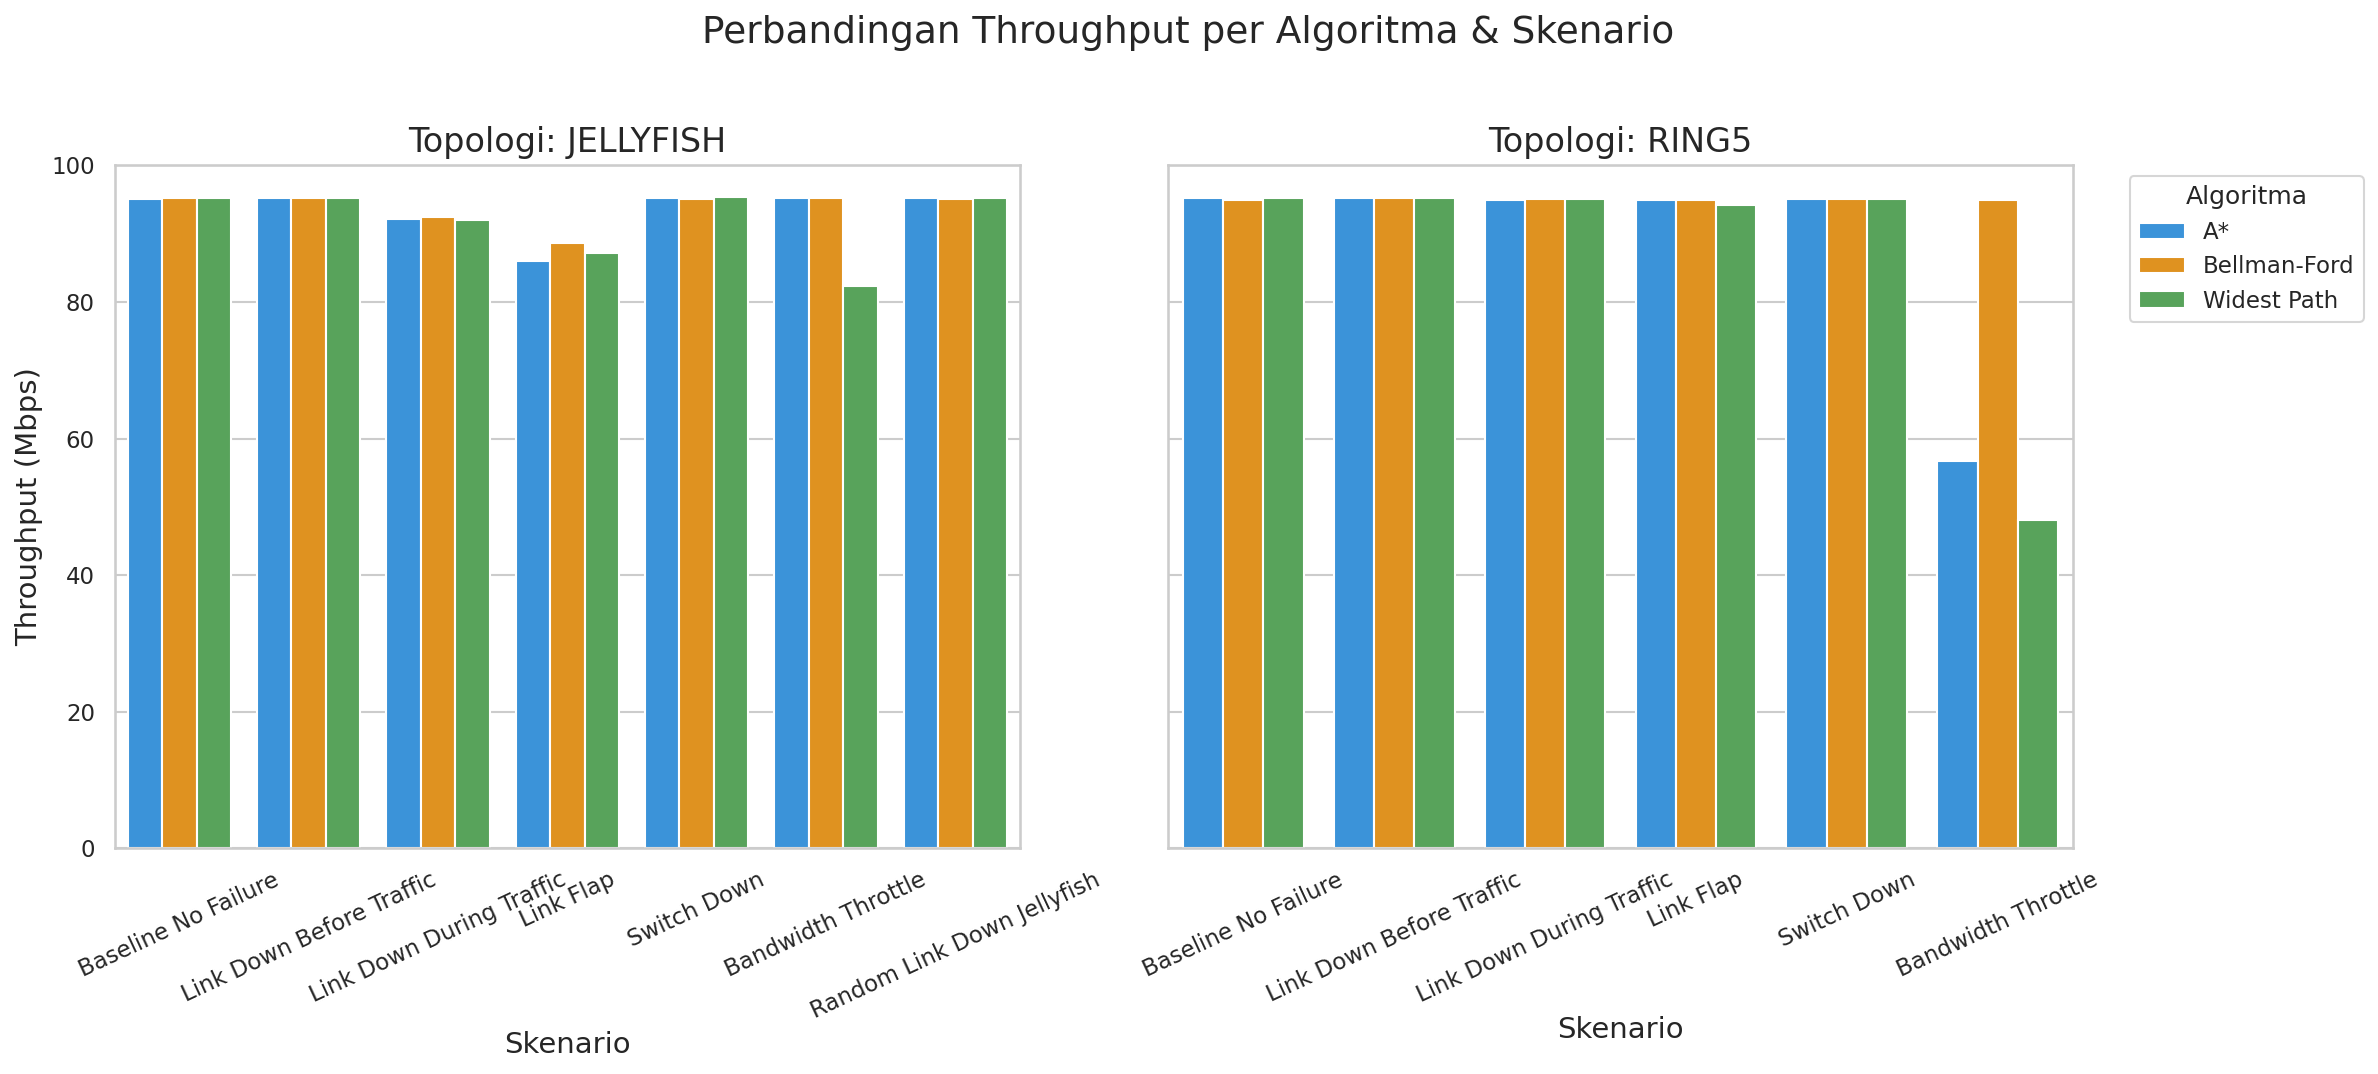

In [ ]:
if not df_ok.empty:
    topos = sorted(df_ok['topology'].unique())
    fig, axes = plt.subplots(1, len(topos), figsize=(8*len(topos), 7), sharey=True)
    if len(topos) == 1:
        axes = [axes]

    for ax, topo in zip(axes, topos):
        data = df_ok[df_ok['topology'] == topo]
        sns.barplot(data=data, x='scenario_label', y='throughput_mbps',
                    hue='algo_label', palette=list(ALGO_COLORS.values()),
                    hue_order=[ALGO_LABELS[a] for a in ALGO_COLORS],
                    errorbar=None, ax=ax)
        ax.set_title(f'Topologi: {topo.upper()}')
        ax.set_xlabel('Skenario')
        ax.set_ylabel('Throughput (Mbps)' if ax == axes[0] else '')
        ax.tick_params(axis='x', rotation=25)
        if ax != axes[-1]:
            ax.get_legend().remove()
        else:
            ax.legend(title='Algoritma', bbox_to_anchor=(1.05, 1), loc='upper left')

    fig.suptitle('Perbandingan Throughput per Algoritma & Skenario', fontsize=18, y=1.02)
    plt.tight_layout()
    save_figure(fig, 'throughput_by_topology')
    plt.show()

---
### Cell 7B: Runtime Distribution
Box plot distribusi runtime komputasi jalur.

  Saved: runtime_distribution.png + .svg


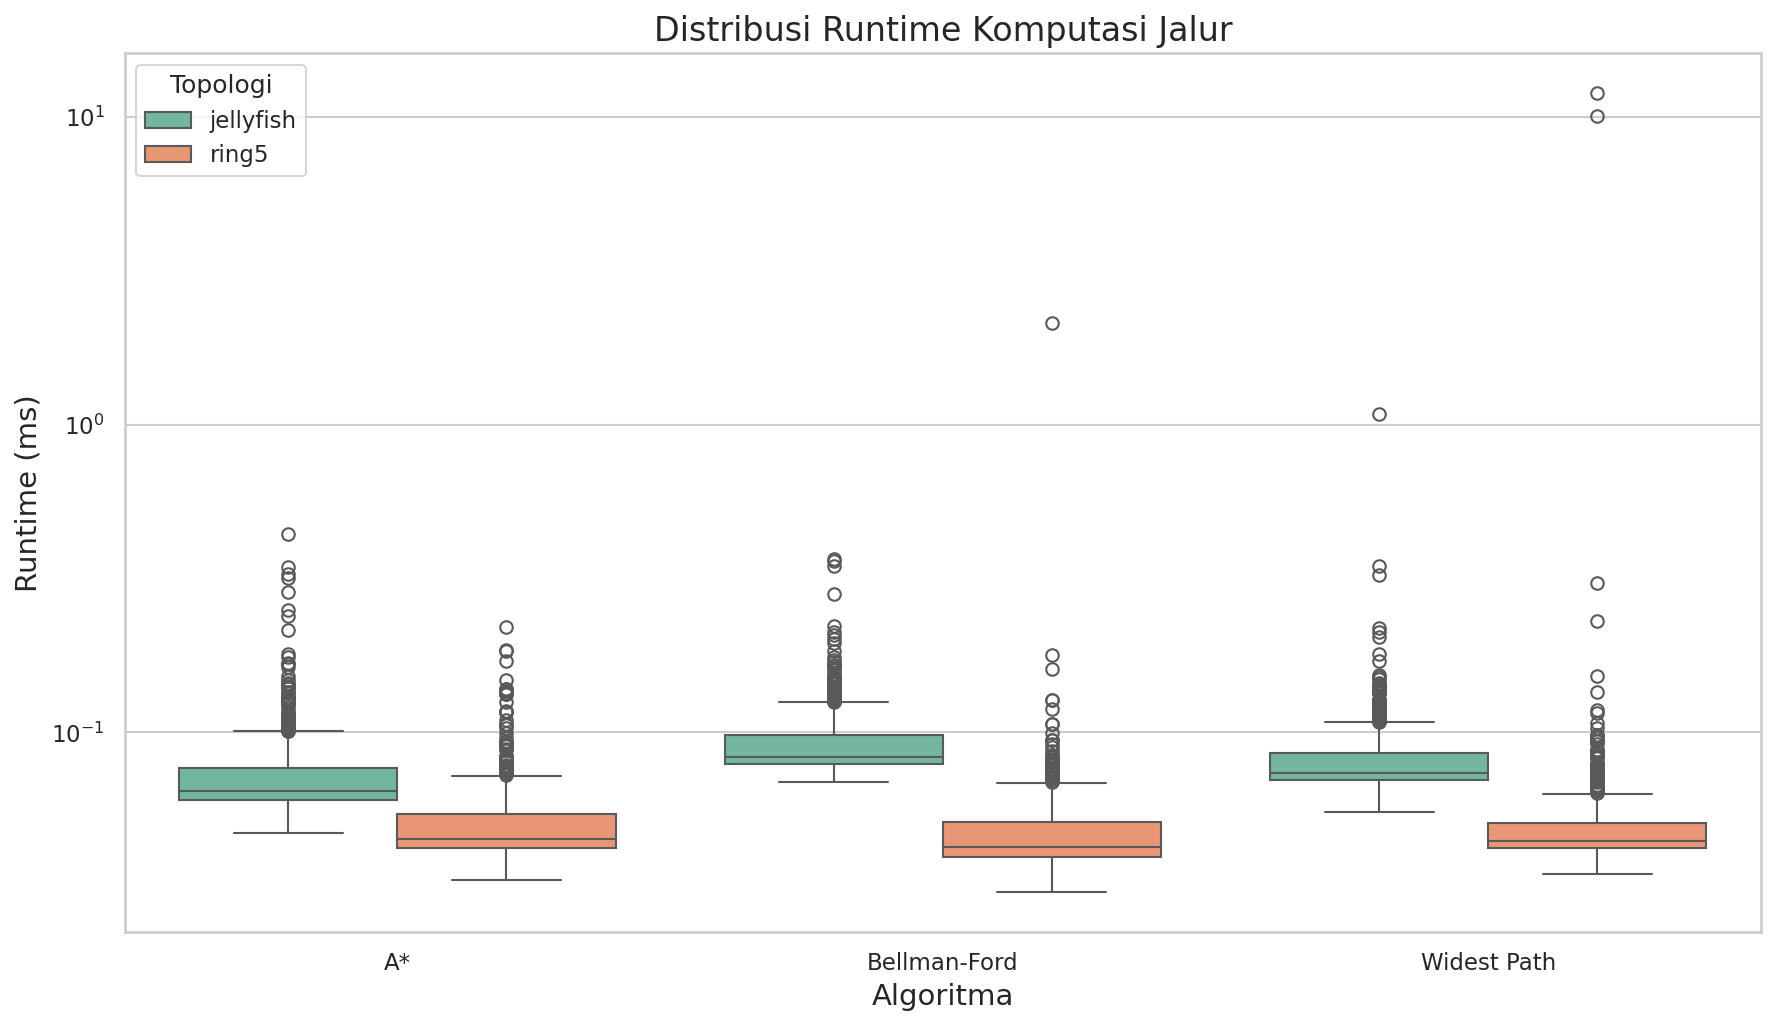

In [ ]:
if not df_ok.empty:
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.boxplot(data=df_ok, x='algo_label', y='runtime_ms',
                hue='topology', palette='Set2', ax=ax,
                order=[ALGO_LABELS[a] for a in ALGO_COLORS])
    ax.set_title('Distribusi Runtime Komputasi Jalur')
    ax.set_xlabel('Algoritma')
    ax.set_ylabel('Runtime (ms)')
    ax.set_yscale('log')
    ax.legend(title='Topologi')
    plt.tight_layout()
    save_figure(fig, 'runtime_distribution')
    plt.show()

---
### Cell 7C: Packet Loss by Scenario
Bar plot persentase packet loss per skenario.

  Saved: packet_loss_by_scenario.png + .svg


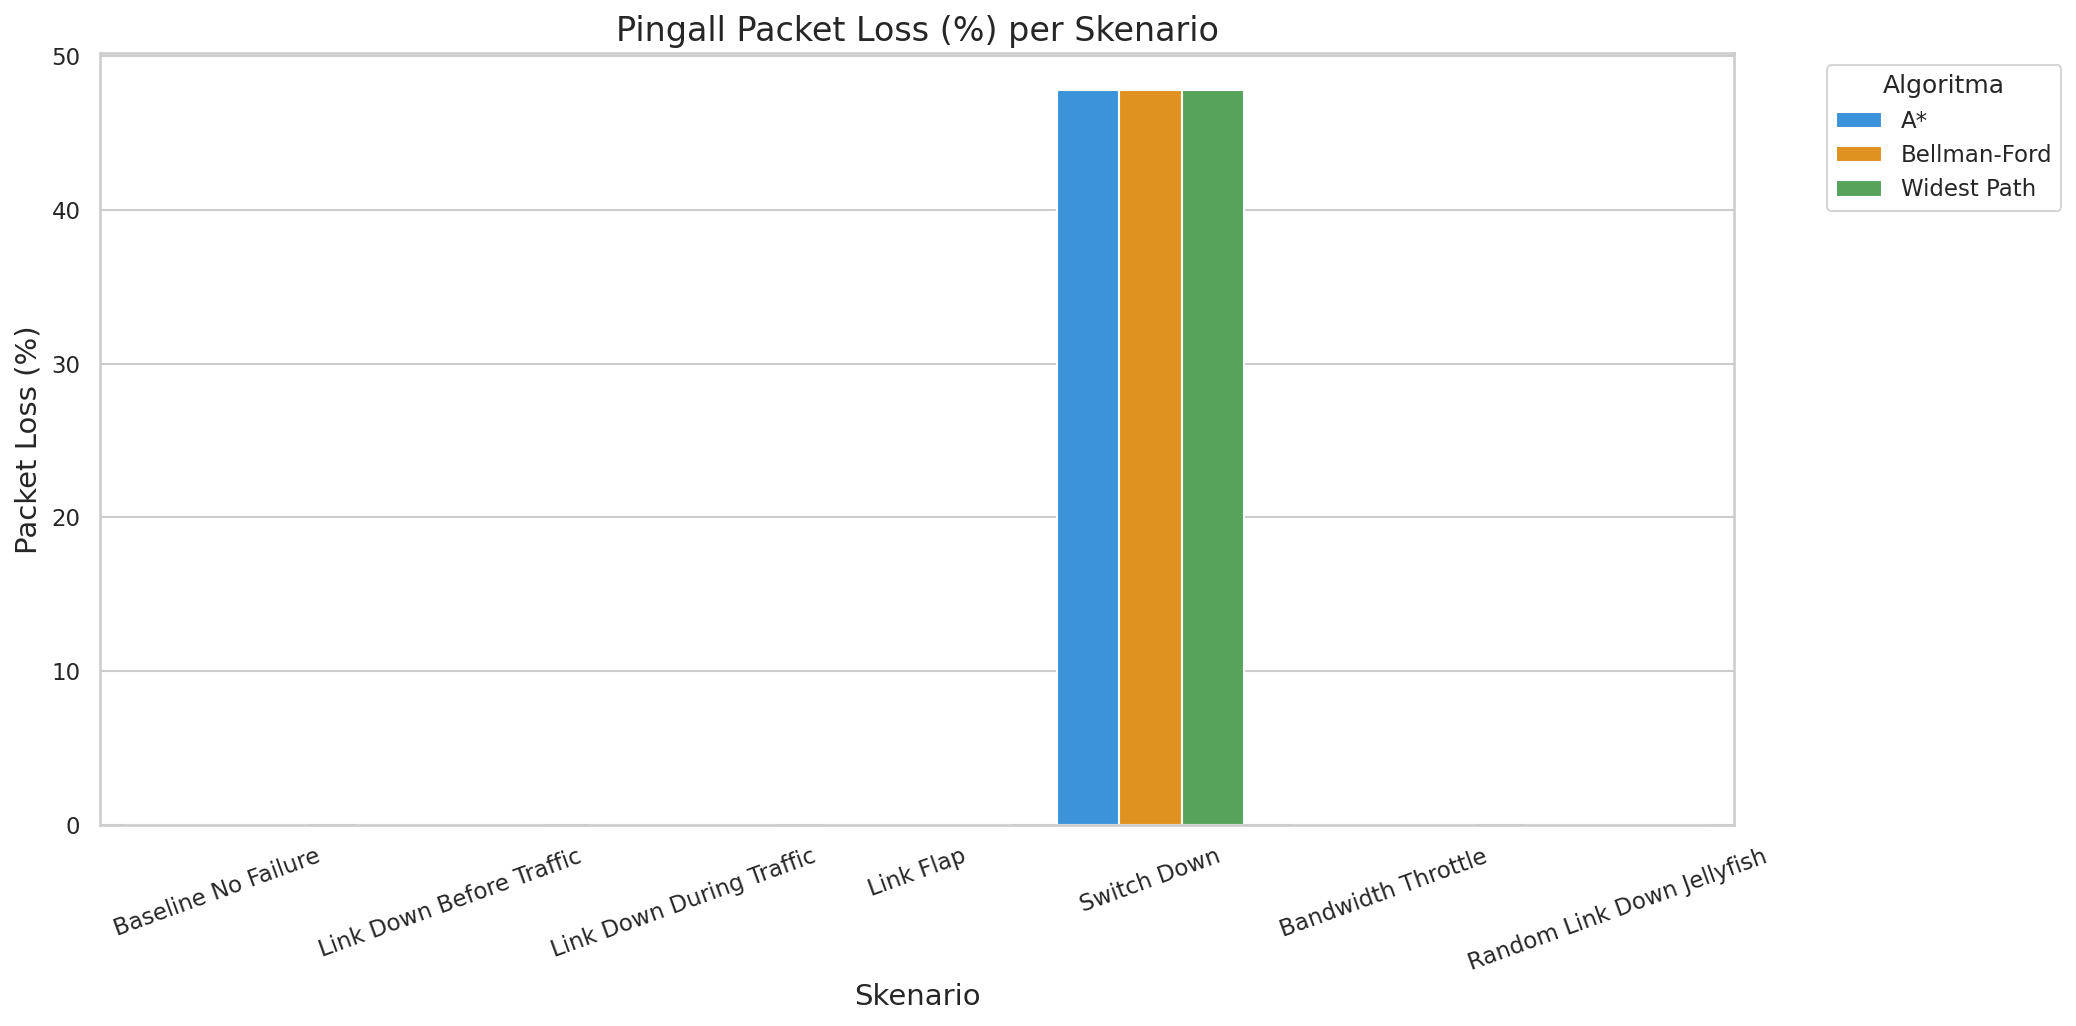

In [ ]:
if not df_ok.empty:
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.barplot(data=df_ok, x='scenario_label', y='pingall_loss_pct',
                hue='algo_label', palette=list(ALGO_COLORS.values()),
                hue_order=[ALGO_LABELS[a] for a in ALGO_COLORS],
                errorbar=None, ax=ax)
    ax.set_title('Pingall Packet Loss (%) per Skenario')
    ax.set_xlabel('Skenario')
    ax.set_ylabel('Packet Loss (%)')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Algoritma', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    save_figure(fig, 'packet_loss_by_scenario')
    plt.show()

---
### Cell 7D: Hop Count Comparison
Bar plot rata-rata hop count per algoritma per topologi.

  Saved: hop_count_comparison.png + .svg


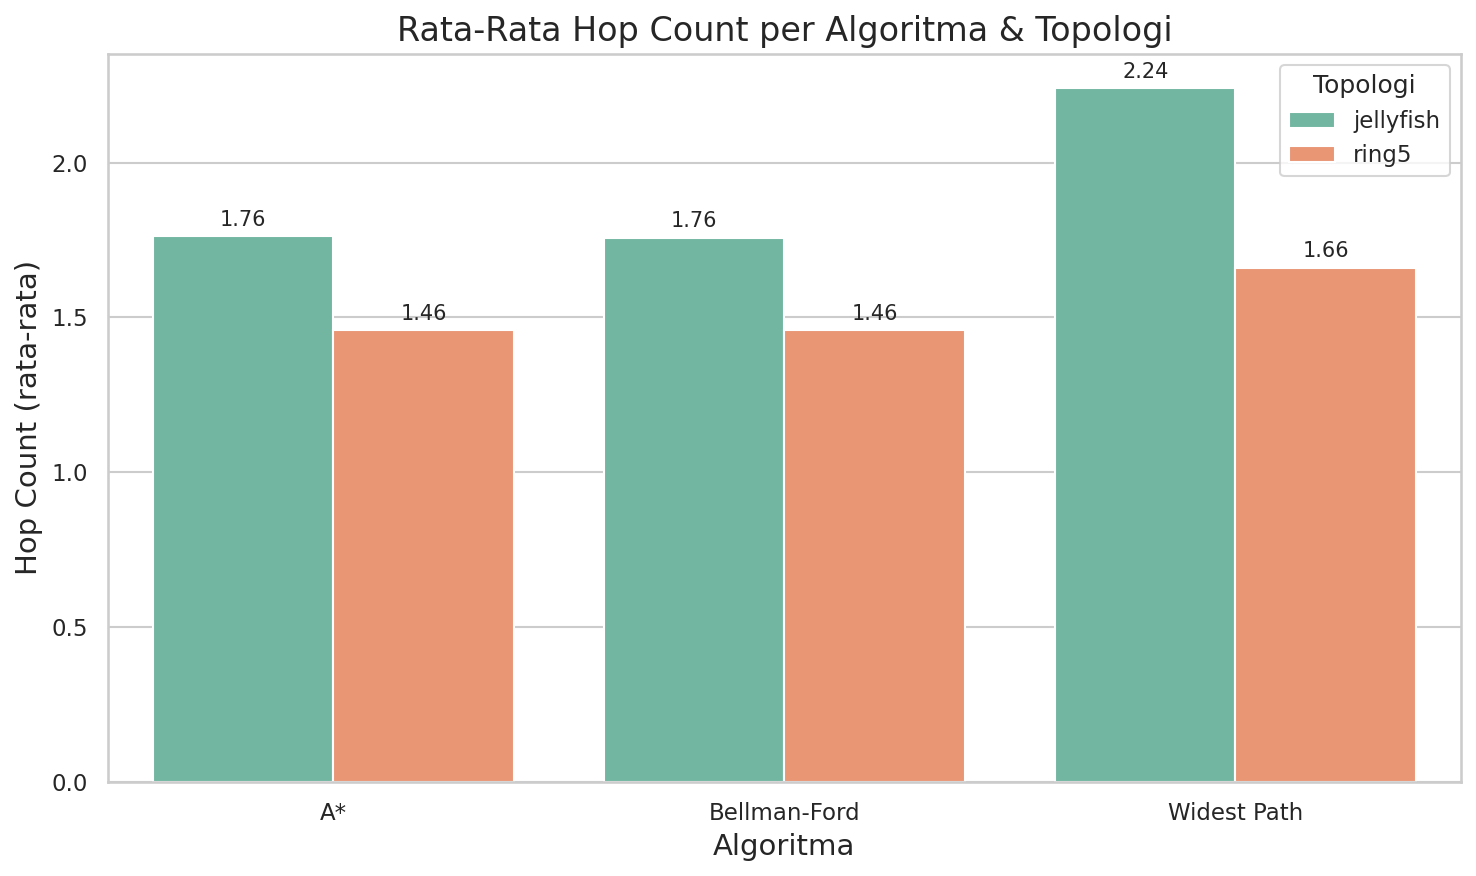

In [ ]:
if not df_ok.empty:
    hop_data = df_ok.groupby(['topology','algo_label'])['hop_count'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=hop_data, x='algo_label', y='hop_count',
                hue='topology', palette='Set2', ax=ax,
                order=[ALGO_LABELS[a] for a in ALGO_COLORS])
    ax.set_title('Rata-Rata Hop Count per Algoritma & Topologi')
    ax.set_xlabel('Algoritma')
    ax.set_ylabel('Hop Count (rata-rata)')
    ax.legend(title='Topologi')

    # Annotate bar values
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=10, padding=3)

    plt.tight_layout()
    save_figure(fig, 'hop_count_comparison')
    plt.show()

---
### Cell 7E: Failure Recovery Chart
Grouped bar chart membandingkan throughput per fase skenario (baseline vs pre vs during).

  Saved: failure_recovery_analysis.png + .svg


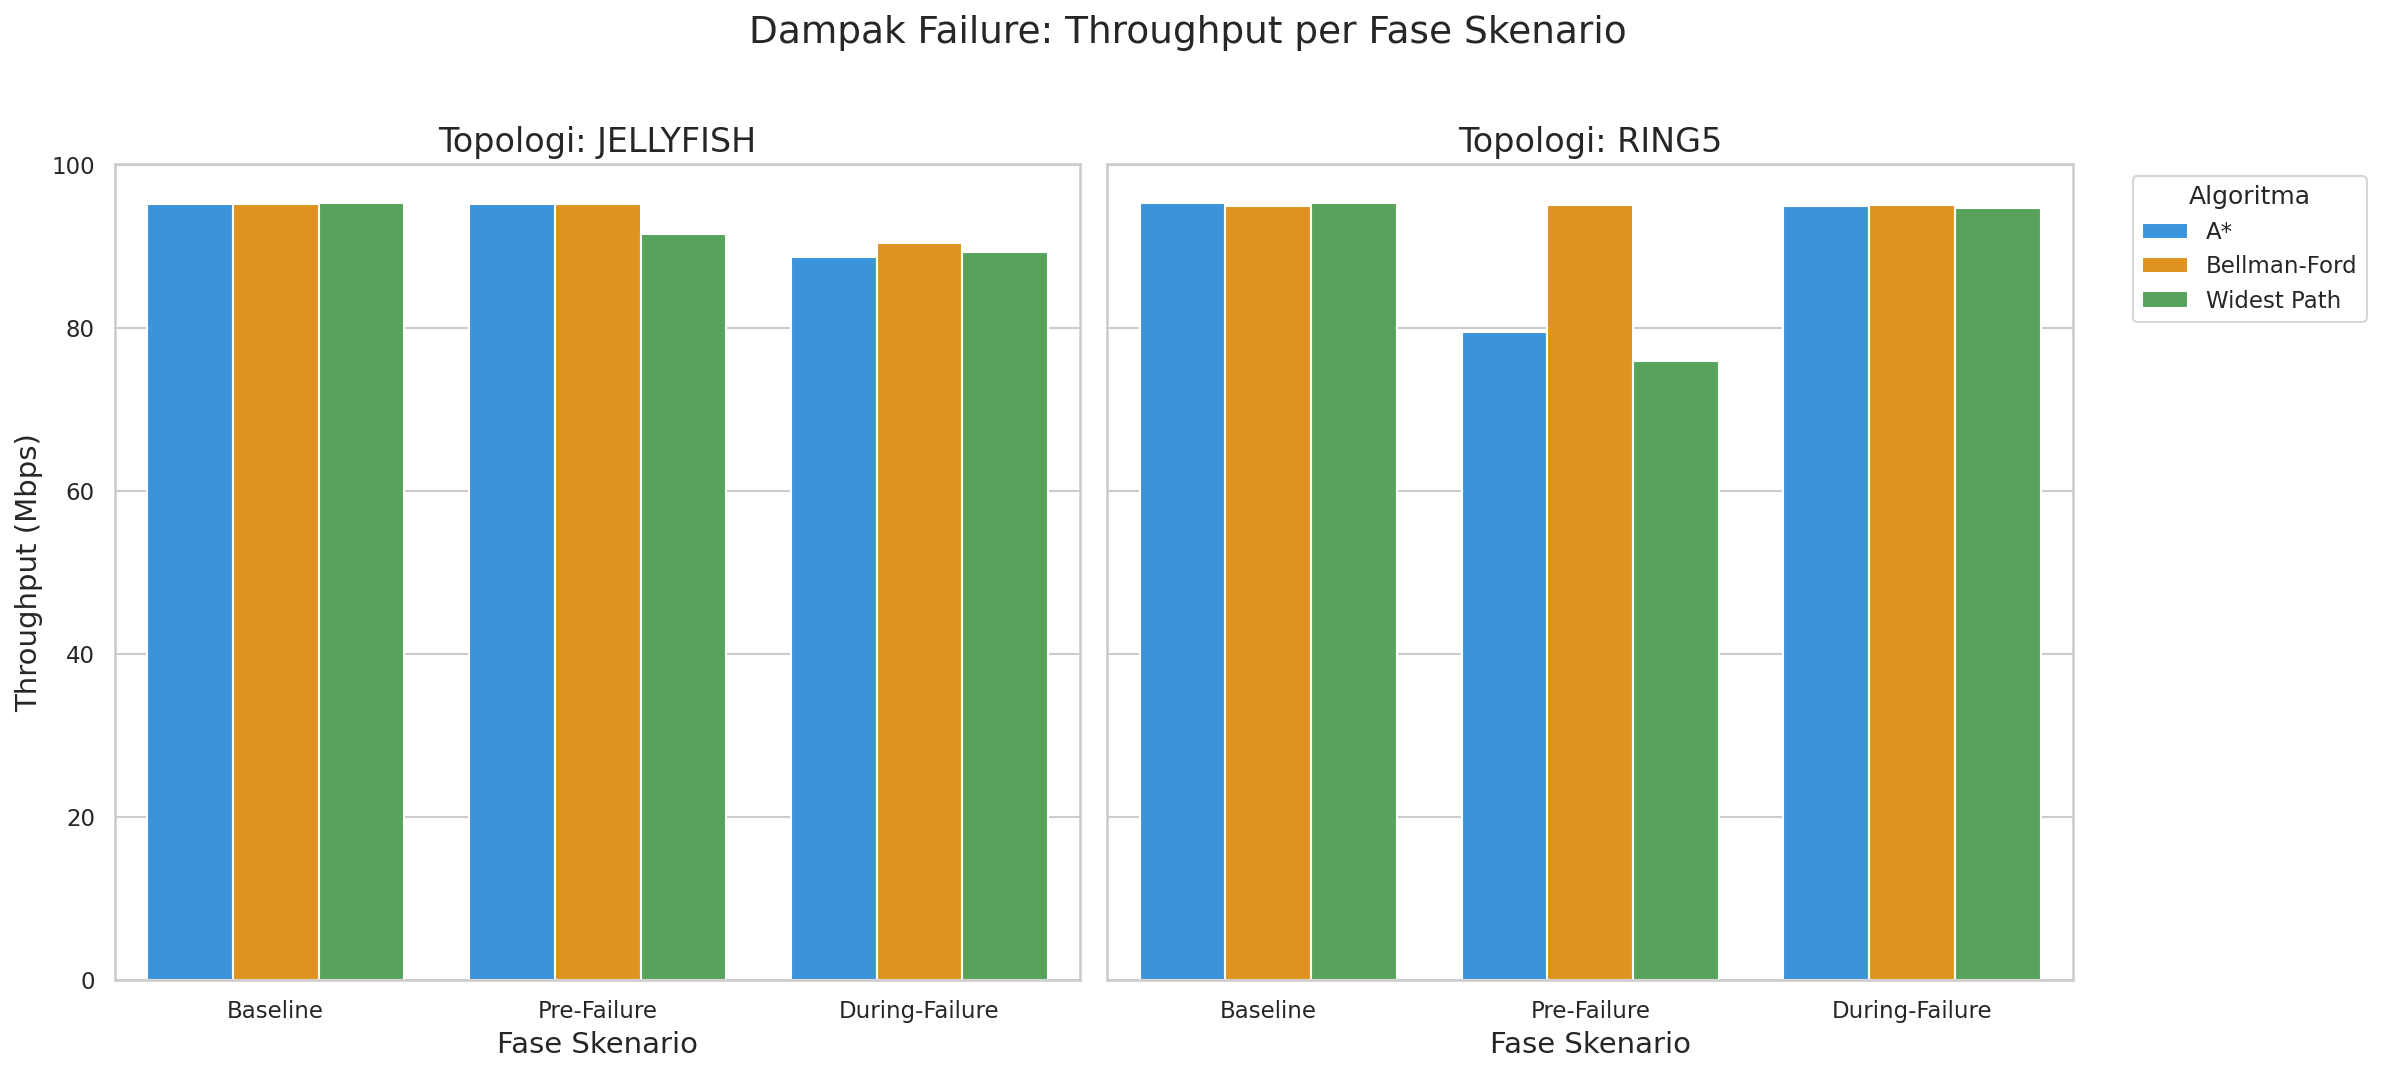

In [ ]:
if not df_ok.empty:
    topos = sorted(df_ok['topology'].unique())
    phase_order = ['baseline', 'pre', 'during']
    phase_labels = {'baseline': 'Baseline', 'pre': 'Pre-Failure', 'during': 'During-Failure'}

    fig, axes = plt.subplots(1, len(topos), figsize=(8*len(topos), 7), sharey=True)
    if len(topos) == 1:
        axes = [axes]

    for ax, topo in zip(axes, topos):
        data = df_ok[df_ok['topology'] == topo].copy()
        # Hanya fase yang ada di data
        avail_phases = [p for p in phase_order if p in data['scenario_phase'].values]
        data['phase_label'] = data['scenario_phase'].map(phase_labels)

        phase_agg = data.groupby(['phase_label','algo_label'])['throughput_mbps'].mean().reset_index()
        order = [phase_labels[p] for p in avail_phases]

        sns.barplot(data=phase_agg, x='phase_label', y='throughput_mbps',
                    hue='algo_label', palette=list(ALGO_COLORS.values()),
                    hue_order=[ALGO_LABELS[a] for a in ALGO_COLORS],
                    order=order, ax=ax)
        ax.set_title(f'Topologi: {topo.upper()}')
        ax.set_xlabel('Fase Skenario')
        ax.set_ylabel('Throughput (Mbps)' if ax == axes[0] else '')
        if ax != axes[-1]:
            ax.get_legend().remove()
        else:
            ax.legend(title='Algoritma', bbox_to_anchor=(1.05, 1), loc='upper left')

    fig.suptitle('Dampak Failure: Throughput per Fase Skenario', fontsize=18, y=1.02)
    plt.tight_layout()
    save_figure(fig, 'failure_recovery_analysis')
    plt.show()

---
#### Interpretasi Failure Recovery

Grafik di atas menampilkan perubahan throughput rata-rata pada tiga fase:
- **Baseline** — kondisi jaringan normal tanpa gangguan
- **Pre-Failure** — pengukuran sebelum traffic dimulai (link sudah down, atau throttle sudah diterapkan)
- **During-Failure** — pengukuran saat traffic berjalan bersamaan dengan gangguan

> Penurunan throughput dari baseline ke during menunjukkan **resiliensi algoritma** terhadap gangguan jaringan. Algoritma dengan delta kecil lebih tahan terhadap failure.

---
### Cell 7F: Throughput Boxplot per Topology
Box plot distribusi throughput per skenario, faceted per topologi.

  Saved: throughput_boxplot_per_topo.png + .svg


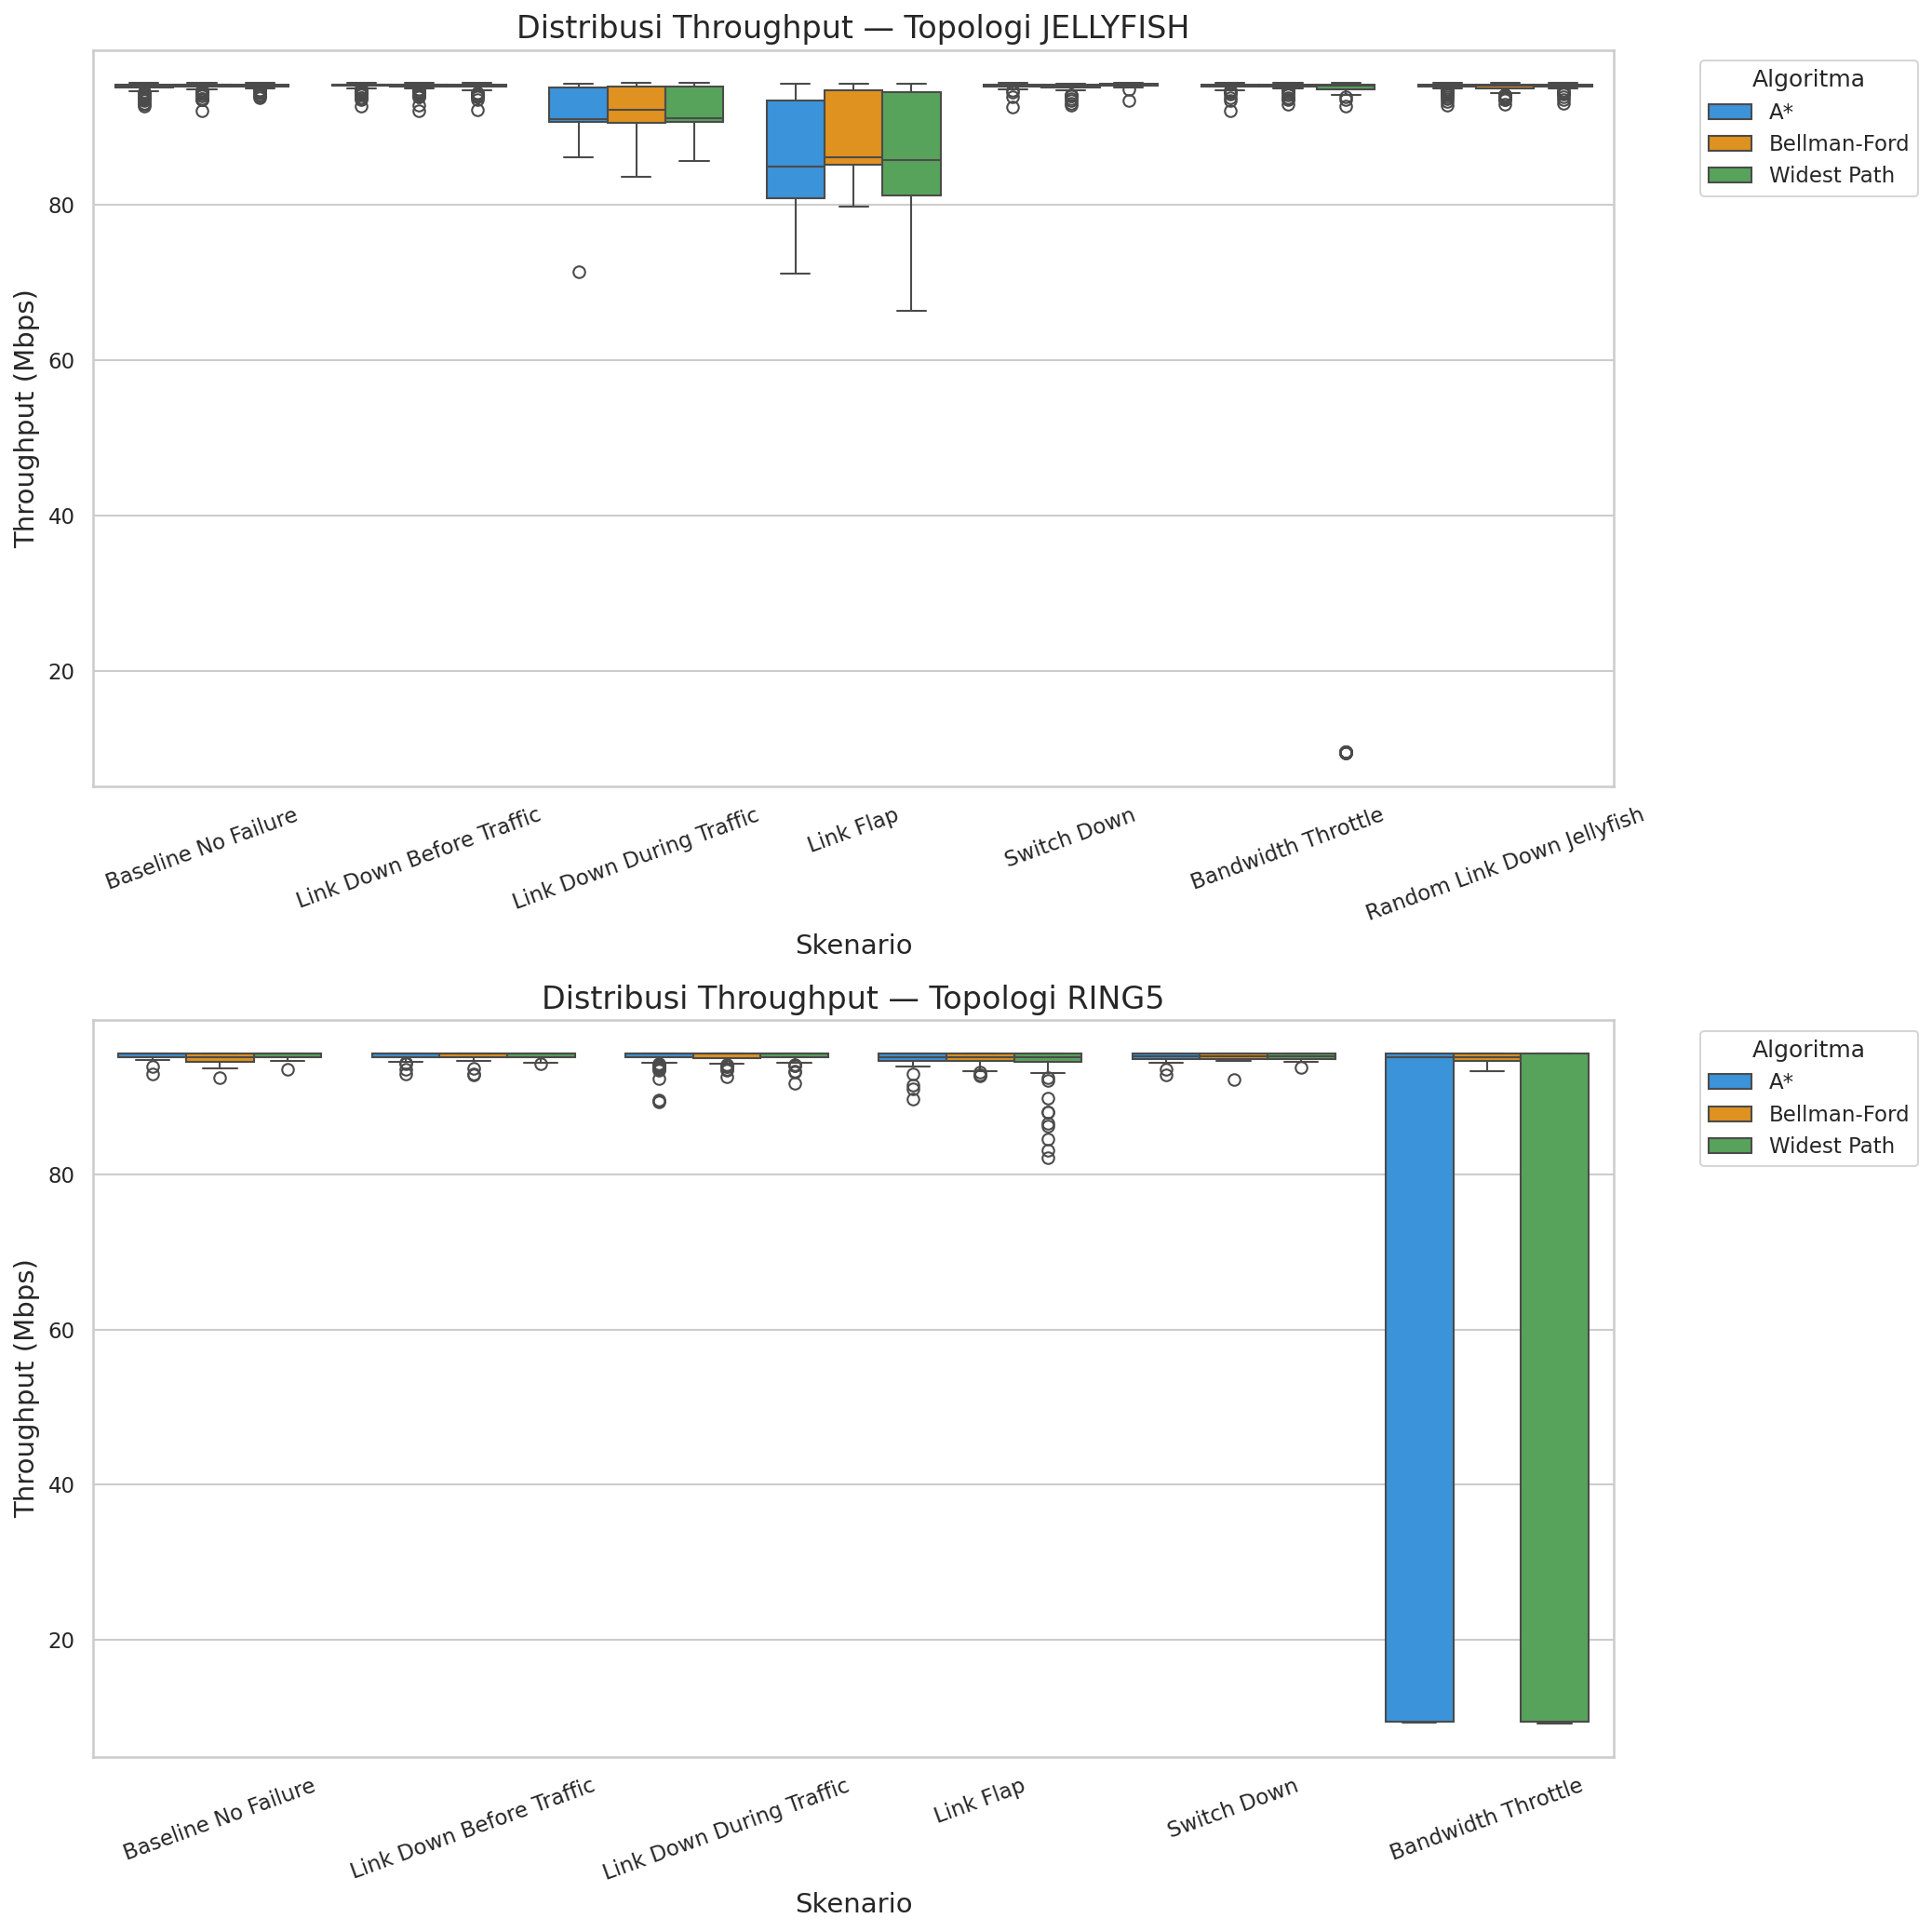

In [ ]:
if not df_ok.empty:
    topos = sorted(df_ok['topology'].unique())
    fig, axes = plt.subplots(len(topos), 1, figsize=(14, 7*len(topos)))
    if len(topos) == 1:
        axes = [axes]

    for ax, topo in zip(axes, topos):
        data = df_ok[df_ok['topology'] == topo]
        sns.boxplot(data=data, x='scenario_label', y='throughput_mbps',
                    hue='algo_label', palette=list(ALGO_COLORS.values()),
                    hue_order=[ALGO_LABELS[a] for a in ALGO_COLORS],
                    ax=ax)
        ax.set_title(f'Distribusi Throughput — Topologi {topo.upper()}')
        ax.set_xlabel('Skenario')
        ax.set_ylabel('Throughput (Mbps)')
        ax.tick_params(axis='x', rotation=20)
        ax.legend(title='Algoritma', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    save_figure(fig, 'throughput_boxplot_per_topo')
    plt.show()

---
### Cell 7G: Retransmits Analysis
Bar plot total TCP retransmits per algoritma per skenario.

  Saved: retransmits_analysis.png + .svg


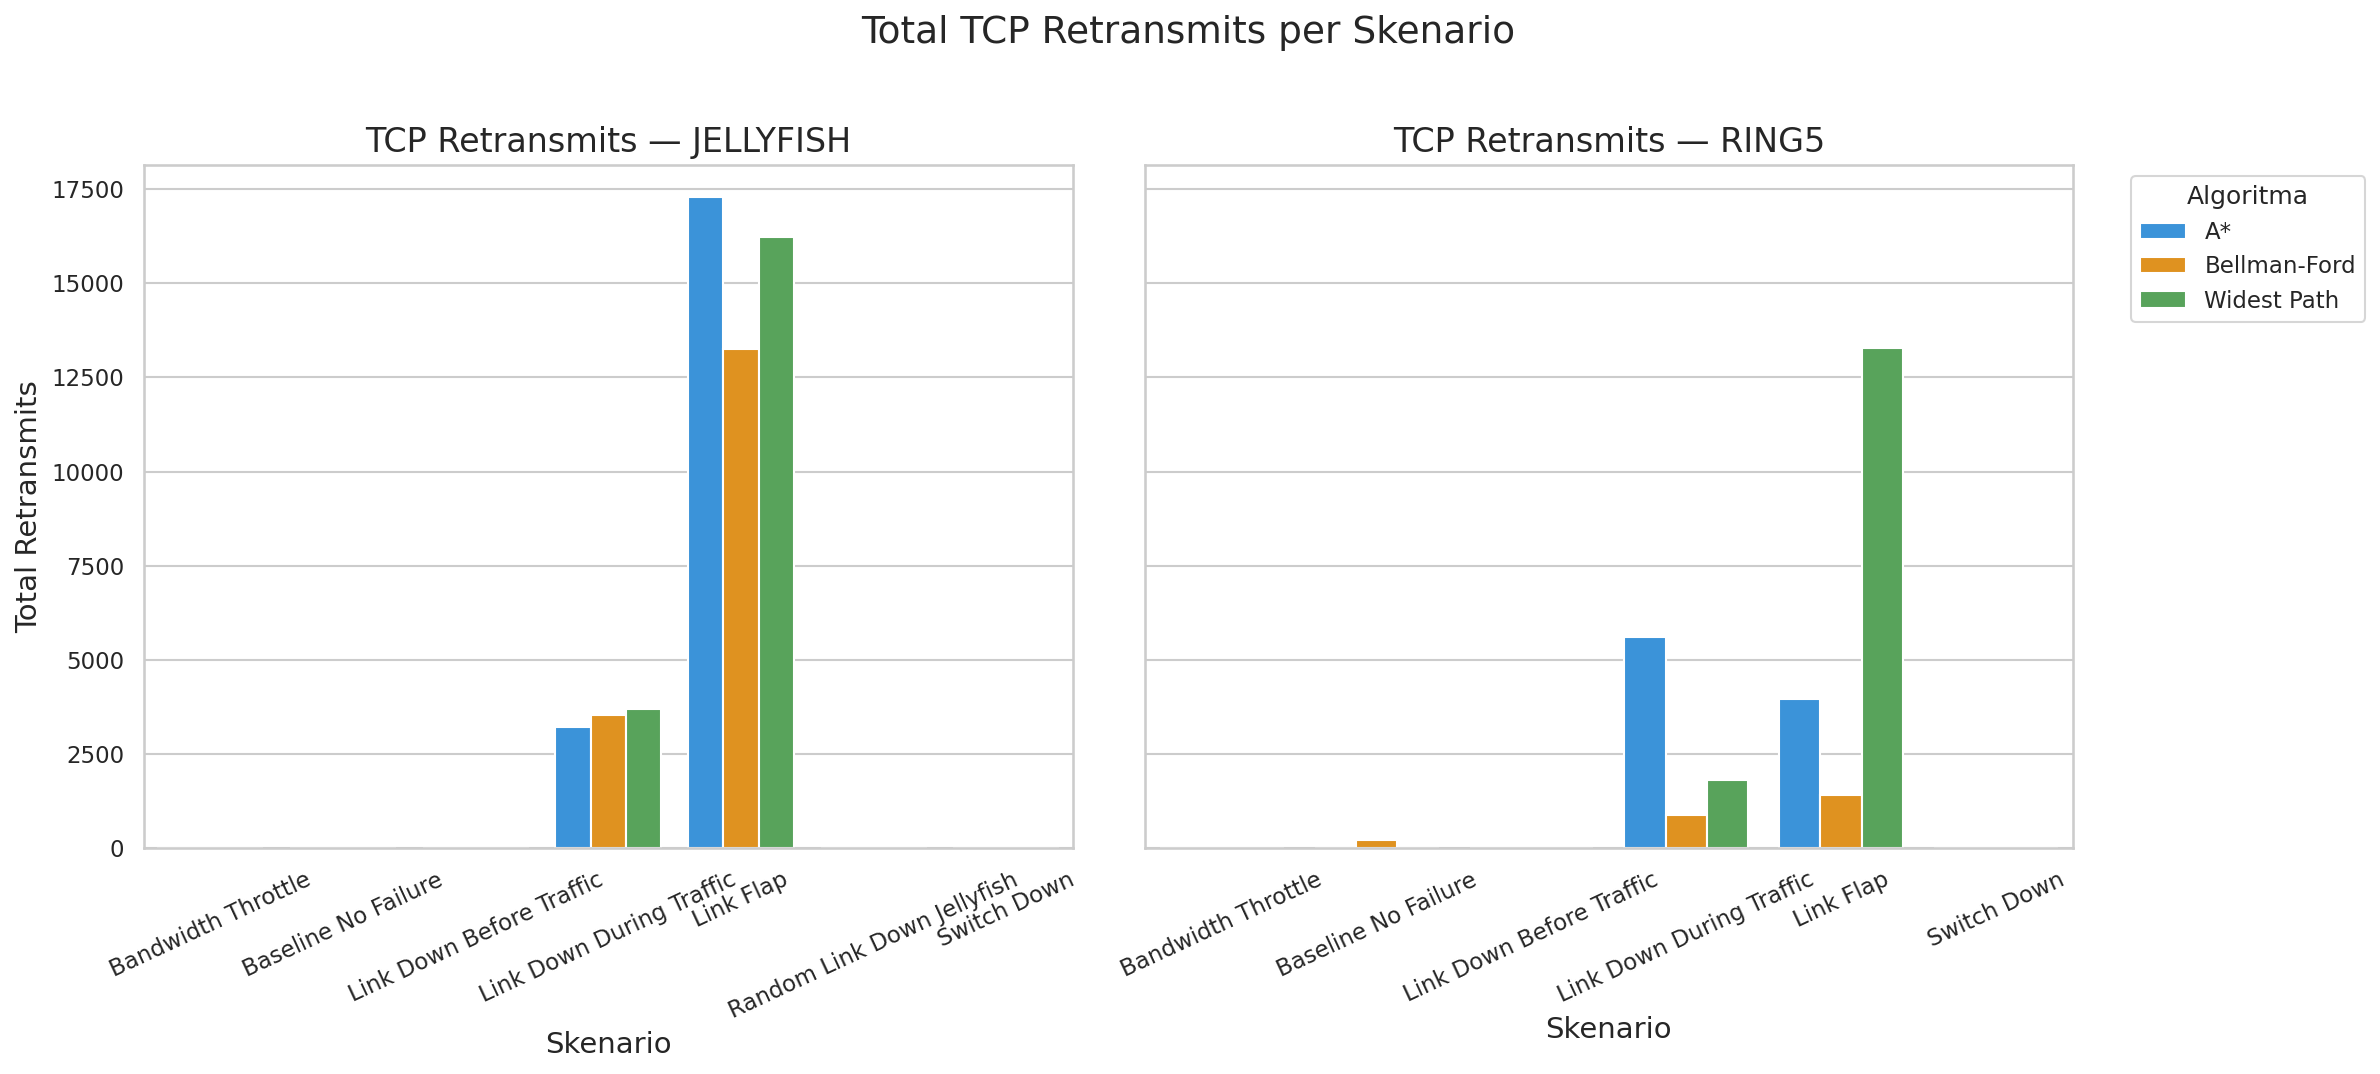

In [ ]:
if not df_ok.empty and 'retransmits' in df_ok.columns and df_ok['retransmits'].notna().any():
    retrans_data = df_ok.groupby(['topology','algo_label','scenario_label'])['retransmits'].sum().reset_index()

    topos = sorted(retrans_data['topology'].unique())
    fig, axes = plt.subplots(1, len(topos), figsize=(8*len(topos), 7), sharey=True)
    if len(topos) == 1:
        axes = [axes]

    for ax, topo in zip(axes, topos):
        data = retrans_data[retrans_data['topology'] == topo]
        sns.barplot(data=data, x='scenario_label', y='retransmits',
                    hue='algo_label', palette=list(ALGO_COLORS.values()),
                    hue_order=[ALGO_LABELS[a] for a in ALGO_COLORS],
                    errorbar=None, ax=ax)
        ax.set_title(f'TCP Retransmits — {topo.upper()}')
        ax.set_xlabel('Skenario')
        ax.set_ylabel('Total Retransmits' if ax == axes[0] else '')
        ax.tick_params(axis='x', rotation=25)
        if ax != axes[-1]:
            ax.get_legend().remove()
        else:
            ax.legend(title='Algoritma', bbox_to_anchor=(1.05, 1), loc='upper left')

    fig.suptitle('Total TCP Retransmits per Skenario', fontsize=18, y=1.02)
    plt.tight_layout()
    save_figure(fig, 'retransmits_analysis')
    plt.show()
else:
    print("Data retransmits tidak tersedia atau seluruhnya nol.")

---
### Cell 7H: Runtime vs Throughput Correlation
Scatter plot untuk melihat hubungan runtime komputasi jalur dengan throughput aktual.

  Saved: runtime_vs_throughput.png + .svg


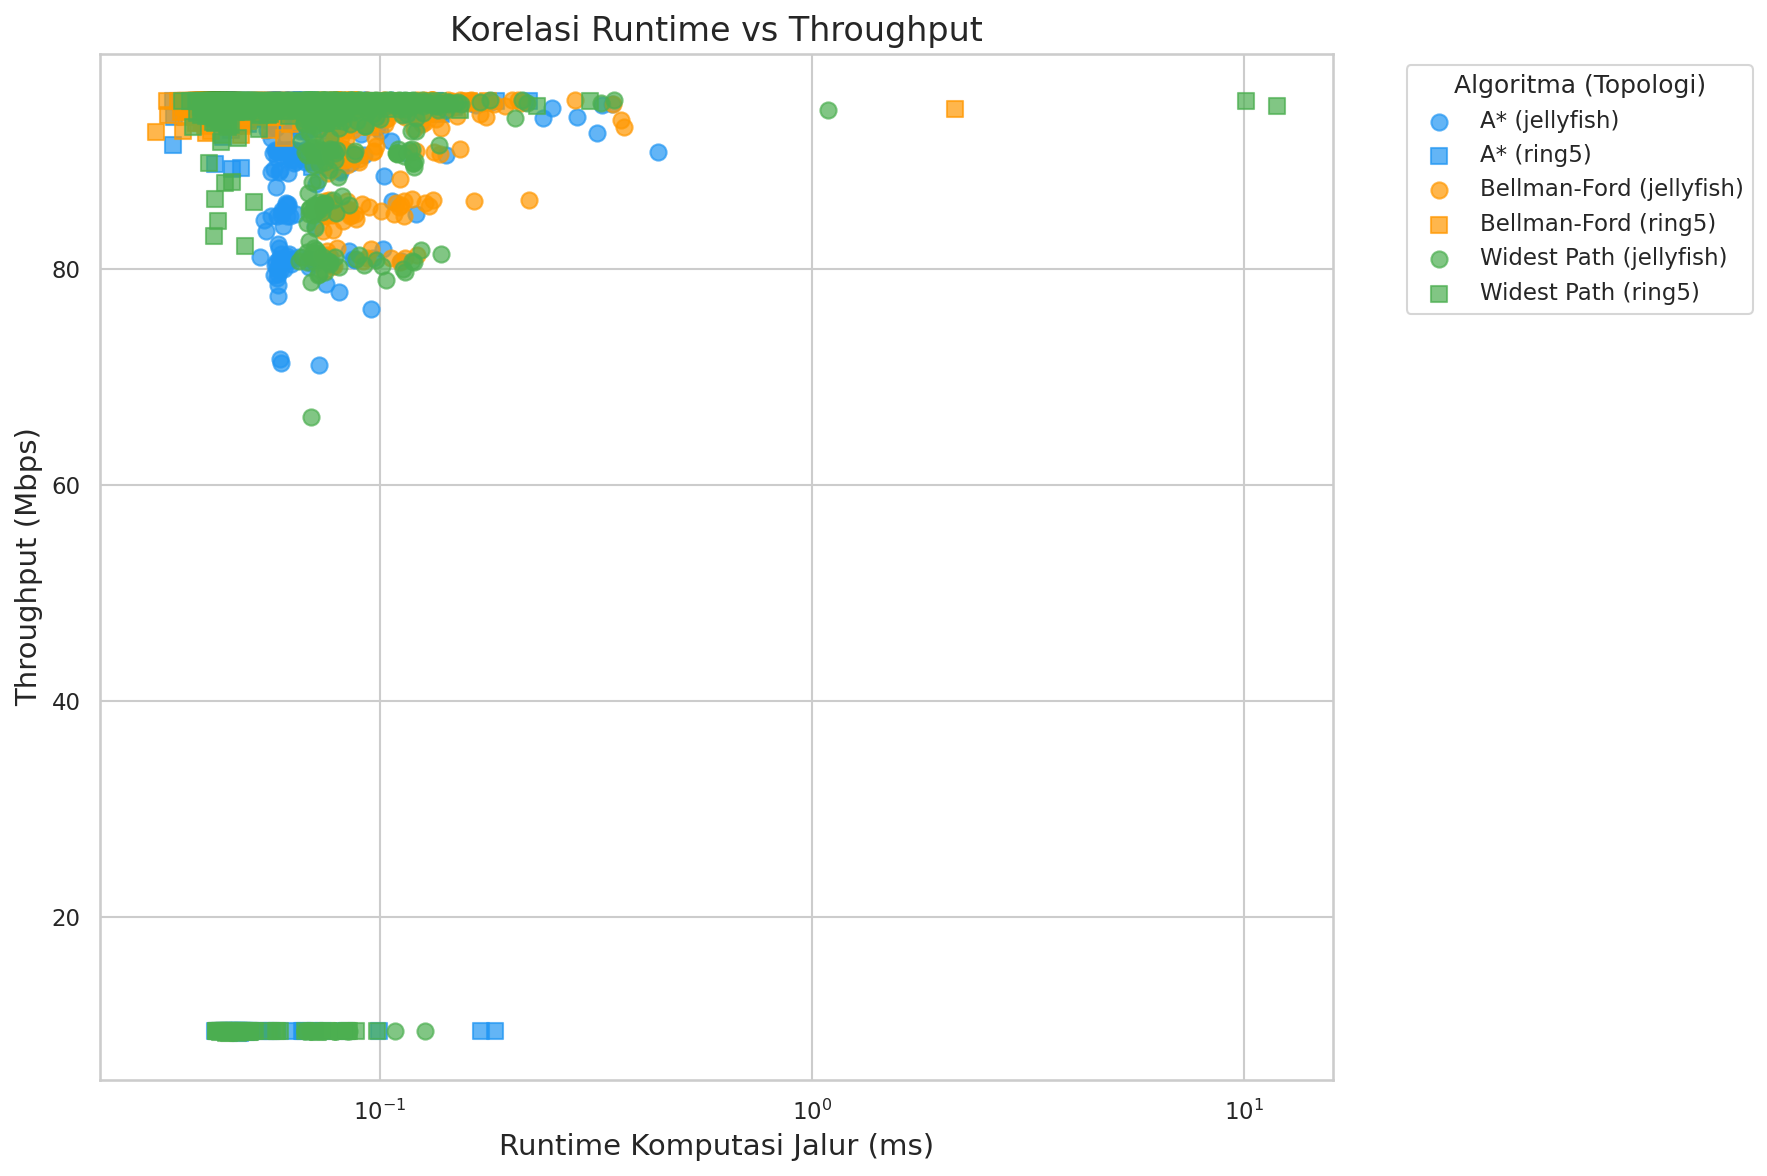

In [ ]:
if not df_ok.empty:
    fig, ax = plt.subplots(figsize=(12, 8))

    for algo in ALGO_COLORS:
        for topo in sorted(df_ok['topology'].unique()):
            mask = (df_ok['algorithm'] == algo) & (df_ok['topology'] == topo)
            subset = df_ok[mask]
            if subset.empty:
                continue
            ax.scatter(
                subset['runtime_ms'], subset['throughput_mbps'],
                color=ALGO_COLORS[algo],
                marker=TOPO_MARKERS.get(topo, 'o'),
                alpha=0.7, s=60,
                label=f"{ALGO_LABELS[algo]} ({topo})"
            )

    ax.set_title('Korelasi Runtime vs Throughput')
    ax.set_xlabel('Runtime Komputasi Jalur (ms)')
    ax.set_ylabel('Throughput (Mbps)')
    ax.set_xscale('log')
    ax.legend(title='Algoritma (Topologi)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    save_figure(fig, 'runtime_vs_throughput')
    plt.show()

---
#### Interpretasi Korelasi Runtime–Throughput

Scatter plot di atas menunjukkan apakah waktu komputasi jalur mempengaruhi throughput aktual yang diukur.

> **Insight umum**: Runtime komputasi jalur terjadi satu kali saat flow pertama kali diminta, sehingga secara teori tidak berkorelasi langsung dengan throughput iperf yang diukur selama 5 detik. Namun, perbedaan runtime antar algoritma mengindikasikan kompleksitas algoritmik yang berbeda.

---
### Cell 8: Export Results
Mengekspor semua tabel ringkasan, ranking, dan failure analysis ke CSV dan Markdown.

In [ ]:
if not df_ok.empty:
    # 1. Summary statistics
    summary_stats.to_csv(ANALYSIS_OUT_DIR / "summary_statistics.csv", index=False)
    print(f"✅ summary_statistics.csv")

    # 2. Ranking per topology
    ranking_display.to_csv(ANALYSIS_OUT_DIR / "ranking_per_topology.csv", index=False)
    print(f"✅ ranking_per_topology.csv")

    # 3. Failure analysis
    if "fail_summary" in dir() and fail_summary is not None:
        fail_summary.to_csv(ANALYSIS_OUT_DIR / "failure_analysis.csv", index=False)
        print(f"✅ failure_analysis.csv")

    # 4. Error records
    if not df_errors.empty:
        err_out = ANALYSIS_OUT_DIR / "error_records.csv"
        df_errors.to_csv(err_out, index=False)
        print(f"✅ error_records.csv ({len(df_errors)} rows)")

    # 5. Full summary markdown
    with open(ANALYSIS_OUT_DIR / "full_summary_tables.md", "w", encoding="utf-8") as f:
        f.write("# SPF Performance Evaluation — Summary Tables\n\n")
        f.write("## 1. Rata-Rata Throughput (Mbps)\n\n")
        f.write(tp.round(2).to_markdown() + "\n\n")
        f.write("## 2. Rata-Rata Runtime Komputasi Jalur (ms)\n\n")
        f.write(rp.round(4).to_markdown() + "\n\n")
        f.write("## 3. Rata-Rata Hop Count\n\n")
        f.write(hp.round(2).to_markdown() + "\n\n")
        f.write("## 4. Success Rate\n\n")
        f.write(sp.to_markdown() + "\n\n")
        f.write("## 5. Ranking Algoritma per Topologi\n\n")
        f.write(ranking_display.round(4).to_markdown(index=False) + "\n\n")
        if "fi" in dir() and fi is not None:
            f.write("## 6. Failure Impact: Δ Throughput vs Baseline (%)\n\n")
            f.write(fi.round(2).to_markdown() + "\n\n")
    print(f"✅ full_summary_tables.md")

    # ══════════════════════════════════════════════════════════
    # 6. LaTeX Tables Export
    # ══════════════════════════════════════════════════════════
    latex_parts = []
    latex_parts.append("% " + "="*60)
    latex_parts.append("% SPF Performance Evaluation — LaTeX Tables")
    latex_parts.append("% Auto-generated by plot_results.ipynb")
    latex_parts.append("% Requires: \\usepackage{booktabs, longtable}")
    latex_parts.append("% " + "="*60)
    latex_parts.append("")

    # Table 1: Throughput
    latex_parts.append("% --- Table 1: Rata-Rata Throughput (Mbps) ---")
    latex_parts.append(tp.round(2).to_latex(
        caption="Rata-Rata Throughput (Mbps) per Algoritma dan Skenario",
        label="tab:throughput",
        bold_rows=True,
    ))

    # Table 2: Runtime
    latex_parts.append("% --- Table 2: Runtime Komputasi Jalur (ms) ---")
    latex_parts.append(rp.round(4).to_latex(
        caption="Rata-Rata Runtime Komputasi Jalur (ms) per Algoritma dan Skenario",
        label="tab:runtime",
        bold_rows=True,
    ))

    # Table 3: Hop Count
    latex_parts.append("% --- Table 3: Rata-Rata Hop Count ---")
    latex_parts.append(hp.round(2).to_latex(
        caption="Rata-Rata Hop Count per Algoritma dan Skenario",
        label="tab:hopcount",
        bold_rows=True,
    ))

    # Table 4: Ranking
    latex_parts.append("% --- Table 4: Ranking Algoritma per Topologi ---")
    rank_tex = ranking_display.round(4).copy()
    rank_tex.columns = [c.replace("_", " ").title() for c in rank_tex.columns]
    latex_parts.append(rank_tex.to_latex(
        index=False,
        caption="Ranking Algoritma per Topologi (Composite Score)",
        label="tab:ranking",
    ))

    # Table 5: Failure Impact
    if "fi" in dir() and fi is not None:
        latex_parts.append("% --- Table 5: Failure Impact ---")
        latex_parts.append(fi.round(2).to_latex(
            caption="Failure Impact: Delta Throughput vs Baseline (persen)",
            label="tab:failure_impact",
            bold_rows=True,
        ))

    # Table 6: Summary Statistics (longtable)
    latex_parts.append("% --- Table 6: Summary Statistics (longtable) ---")
    ss_tex = summary_stats[[
        "topology", "algorithm", "scenario_label",
        "avg_throughput", "std_throughput", "avg_runtime_ms",
        "avg_hop_count", "avg_loss_pct", "success_rate_%"
    ]].copy()
    ss_tex.columns = [
        "Topologi", "Algoritma", "Skenario",
        "Avg Tput", "Std Tput", "Avg Runtime",
        "Avg Hop", "Avg Loss", "Success Rate"
    ]
    latex_parts.append(ss_tex.round(3).to_latex(
        index=False,
        caption="Statistik Ringkasan per Topologi, Algoritma, dan Skenario",
        label="tab:summary_stats",
        longtable=True,
    ))

    tex_content = "\n".join(latex_parts)
    with open(ANALYSIS_OUT_DIR / "tables.tex", "w", encoding="utf-8") as f:
        f.write(tex_content)
    print(f"✅ tables.tex (LaTeX — 6 tables)")

    # Summary of all exports
    print(f"\n📁 Output gambar : {IMG_DIR.resolve()}")
    print(f"📁 Output CSV/MD/TEX: {ANALYSIS_OUT_DIR.resolve()}")
    img_count = len(list(IMG_DIR.glob("*.*")))
    out_count = len(list(ANALYSIS_OUT_DIR.glob("*.*")))
    print(f"   Total gambar   : {img_count} file(s)")
    print(f"   Total CSV/MD/TEX: {out_count} file(s)")
else:
    print("Data kosong, ekspor dibatalkan.")


✅ summary_statistics.csv
✅ ranking_per_topology.csv
✅ failure_analysis.csv
✅ error_records.csv (389 rows)
✅ full_summary_tables.md
✅ tables.tex (LaTeX — 6 tables)

📁 Output gambar : /content/img/analysis
📁 Output CSV/MD/TEX: /content/analysis_output
   Total gambar   : 16 file(s)
   Total CSV/MD/TEX: 6 file(s)
